# Машинное обучение, ФКН ВШЭ

## Практическое задание 4. Классификация

### Общая информация
Дата выдачи: 16.11.2024

Мягкий дедлайн: 28.11.2024

Жесткий дедлайн: 02.12.2024

### О задании

В этом задании вы:
- ознакомитесь с тем, что происходит "внутри" метода опорных векторов и логистической регрессии
- познакомитесь с калибровкой вероятности
- изучите методы трансформации переменных и методы отбора признаков
- попробуете оценить экономический эффект модели

----

#### Самостоятельная оценка результатов

Для удобства проверки, исходя из набора решенных задач, посчитайте свою максимальную оценку.

**Оценка**: 10.5 (из них 1.5 балла - бонусы)

### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

### Формат сдачи

Для сдачи задания переименуйте получившийся файл *.ipynb в соответствии со следующим форматом: homework-practice-04-linclass-__Username__.ipynb, где Username — ваша фамилия и имя на латинице именно в таком порядке (например, homework-practice-04-linclass-__IvanovIvan__.ipynb).

# Часть 1. SVM, LR и калибровка вероятностей (2 балла + 0.5 бонус)

In [193]:
import numpy as np
import pandas as pd
# import polars as pl
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
# pl.Config().set_tbl_rows(100)
# pl.Config().set_tbl_cols(100)

#### __Задание 1.1  Сравнение методов__ (0.5 балла)



Сгенерируем синтетические данные.

In [194]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# фиксируем random_state для воспроизводимости результатов
X, y = make_classification(
    n_samples=10000, n_features=10, n_informative=5, n_redundant=5, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

__Случайный классификатор__

Для начала зададим самую простую модель, которая на каждом объекте выдаёт случайный ответ. По тестовой выборке вычислим AUC-ROC, AUC-PR.

In [195]:
from sklearn.dummy import DummyClassifier
random_classifier = DummyClassifier(strategy='uniform', random_state=42).fit(X_train, y_train)
y_random = random_classifier.predict_proba(X_test)[:,1]
y_random

array([0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5])

**Вопрос:** решаем задачу бинарной классификации, но y\_random содержит какие-то дробные числа, а не 0/1. Почему?



**Ответ**: потому что ответ модели - степень уверенности модели в том, что объект относится к положительному классу, далее мы подбираем порог, согласно которму уже определяем класс (0/1). Не всегда ответ модели распределен на отрезке от 0 до 1, в общем случае - уверенность модели может бытт числом в любом диапозоне (что не повлияет на вид AUC-ROC), тем не менее в случает с predict_proba мы получаем значения на отрезке от 0 до 1 (но эти значения не откалиброваны, поэтому "вероятностью" - с той точки зрения, что среди объектов с одинаковым прогнозом модели, действительно такой процент будет относиться к положительному классу - их назвать нельзя).

*Ниже приведен **пример** работы* со встроенными функциями `sklearn` для отрисовки ROC и PR кривых, сохранения метрик. Пайплайн можно изменять как вам удобно.

In [196]:
from sklearn.metrics import average_precision_score

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay

from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

from sklearn.model_selection import GridSearchCV

from scipy.special import expit

Random Classifier metrics
AUC-PR: 0.5057
AUC-ROC: 0.5000


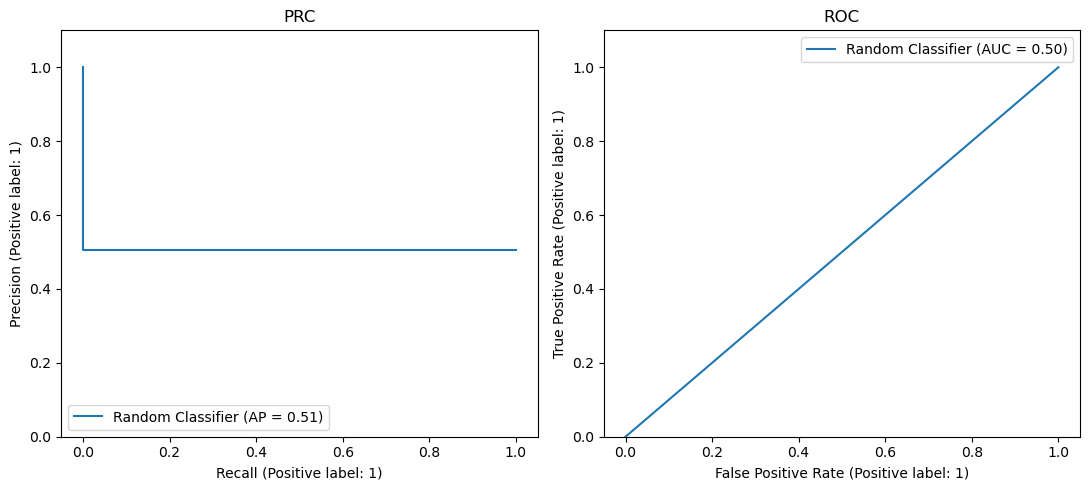

In [197]:
def depict_pr_roc(y_true, y_pred, classifier_name='Some Classifier', ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 2, figsize=(11, 5))

    print(classifier_name, 'metrics')
    PrecisionRecallDisplay.from_predictions(y_true, y_pred, ax=ax[0], name=classifier_name)
    print('AUC-PR: %.4f' % average_precision_score(y_true, y_pred))
    ax[0].set_title("PRC")
    ax[0].set_ylim(0, 1.1)

    RocCurveDisplay.from_predictions(y_true, y_pred, ax=ax[1], name=classifier_name)
    print('AUC-ROC: %.4f' % roc_auc_score(y_true, y_pred))
    ax[1].set_title("ROC")
    ax[1].set_ylim(0, 1.1)

    plt.tight_layout()
    plt.legend()


depict_pr_roc(y_test, y_random, 'Random Classifier')

In [198]:
# dataframe для сравнения
# методов классификации по метрикам
df_metrics = pd.DataFrame(
    columns=['auc_pr', 'roc_auc_score', 'reg_const']
)
precision, recall, _ = precision_recall_curve(y_test, y_random)
# добавление очередной строки с характеристиками метода
df_metrics.loc['Random Classifier'] = [
      average_precision_score(y_test, y_random),
      roc_auc_score(y_test, y_random),
      0,
]

# по аналогии результаты следующих экспериментов можно будет собрать в табличку
df_metrics

,auc_pr,roc_auc_score,reg_const
Random Classifier,0.505667,0.5,0.0


__Support Vector Machine (Linear Kernel)__

Обучите метод опорных векторов.

Подберите параметр регуляризации `C` с точки зрения AUC-PR (можете воспользоваться кросс-валидацией или отделить валидационную выборку от обучающей).


In [199]:
C_svm = {'C': np.logspace(-3, 3, 7)}
model = LinearSVC(dual=False, max_iter=10000) 

grid_search = GridSearchCV(model, C_svm, cv=5, scoring='average_precision', verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 7 candidates, totalling 35 fits


GridSearchCV(cv=5, estimator=LinearSVC(dual=False, max_iter=10000),
             param_grid={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])},
             scoring='average_precision', verbose=1)

In [200]:
best_C = grid_search.best_params_['C']
best_auc_pr = grid_search.best_score_

print(f"эЛучшее значение C: {best_C}")
print(f"Лучшее AUC-PR: {best_auc_pr}")

эЛучшее значение C: 0.01
Лучшее AUC-PR: 0.8233604335050156


  На тестовой части:
  - постройте ROC и PR кривые,
  - посчитайте AUC-ROC, AUC-PR

Проанализируйте, как себя ведут обе кривые:
- Что происходит при увеличении порога? Как бы вы это проинтерпретировали?
- Монотонные ли кривые? Как вы это объясните?

Сравните AUC-ROC и AUC-PR для вашей модели с этими же метриками для случайного классификатора.

In [201]:
y_pred

array([0.54189087, 0.49600829, 0.24619221, 0.1582211 , 0.65474628,
       0.57174076, 0.4041739 , 0.19645434, 0.40904748, 0.44817117,
       0.32264728, 0.27633169, 0.40904748, 0.69581046, 0.71575569,
       0.30419103, 0.4691448 , 0.66494384, 0.4691448 , 0.50117557,
       0.31196905, 0.53867946, 0.29010817, 0.71724618, 0.50512233,
       0.57912353, 0.51365926, 0.43500959, 0.57174076, 0.54715648,
       0.47694173, 0.59607523, 0.45663372, 0.49458003, 0.54189087,
       0.54967525, 0.59790681, 0.23741931, 0.50117557, 0.265429  ,
       0.51511717, 0.73656983, 0.6181632 , 0.49600829, 0.39451925,
       0.43859415, 0.39960425, 0.48747067, 0.52693254, 0.59517083,
       0.69046934, 0.44999067, 0.36559303, 0.53363635, 0.11155112,
       0.50019029, 0.28031827, 0.29796175, 0.64640242, 0.58966735,
       0.57174076, 0.28773169, 0.44816291, 0.57912353, 0.72265413,
       0.55576758, 0.49600829, 0.72411611, 0.34635116, 0.63153622,
       0.37513806, 0.68035339, 0.59215895, 0.19327284, 0.52702

SVM metrics
AUC-PR: 0.8299
AUC-ROC: 0.8476


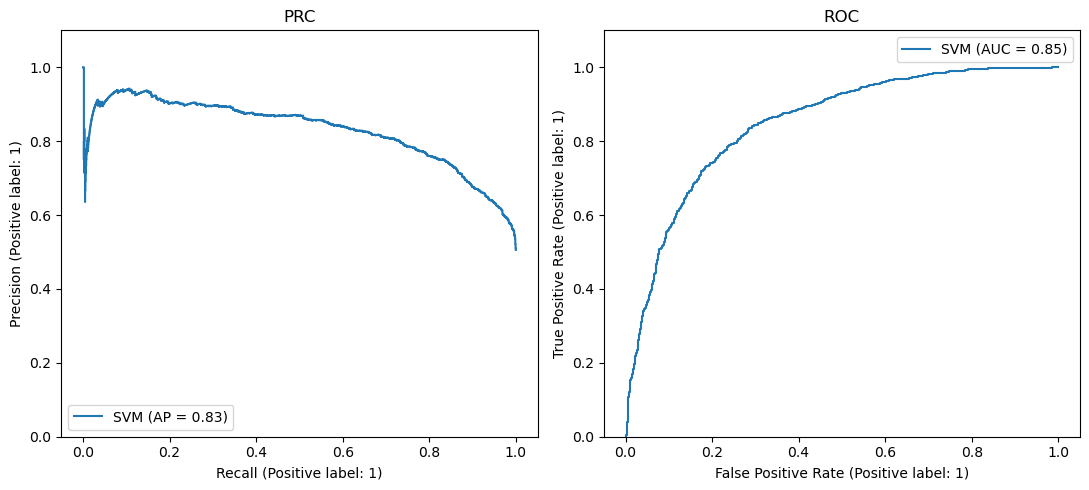

In [202]:
model = LinearSVC(C=best_C)
model.fit(X_train, y_train)

y_pred = model.decision_function(X_test)

depict_pr_roc(y_test, y_pred, classifier_name='SVM')

Обе метрики показали улушчешие относиттельно случайного классификатора 

__Logistic Regression__


Аналогичное задание для логистической регрессии с L2 регуляризатором:


*   подберите гиперпараметр C, используя метрику AUC-PR
*   нарисуйте ROC, PR кривые для тестовой части
*   выведите метрики для тестовых данных и сравните их с результатами случайного классификатора



In [203]:
C_svm = {'C': np.logspace(-3, 3, 7)}
model = LogisticRegression(penalty='l2')

grid_search = GridSearchCV(model, C_svm, cv=5, scoring='average_precision', verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 7 candidates, totalling 35 fits


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])},
             scoring='average_precision', verbose=1)

In [204]:
best_C = grid_search.best_params_['C']
best_auc_pr = grid_search.best_score_

print(f"эЛучшее значение C: {best_C}")
print(f"Лучшее AUC-PR: {best_auc_pr}")

эЛучшее значение C: 0.001
Лучшее AUC-PR: 0.8277305684152289


Нарисуйте ROC, PR кривые для тестовой части для всех 3 классификаторов на одном графике

Random Classifier metrics
AUC-PR: 0.5057
AUC-ROC: 0.5000
SVM metrics
AUC-PR: 0.8299
AUC-ROC: 0.8476
Logistic Regression metrics
AUC-PR: 0.8338
AUC-ROC: 0.8453


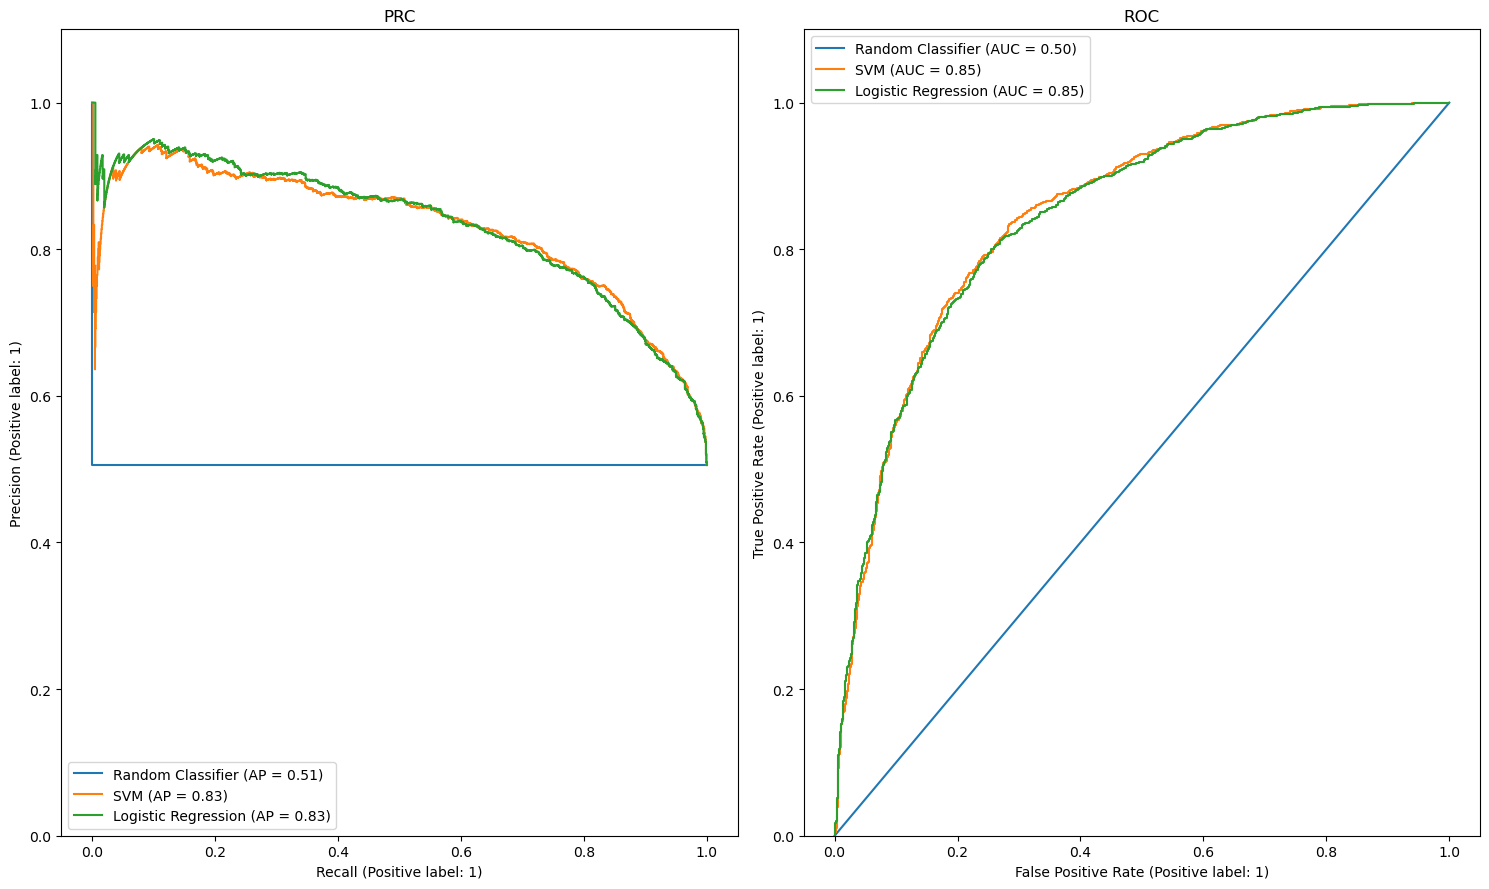

In [205]:
model = LogisticRegression(penalty='l2', C=best_C)
model.fit(X_train, y_train)

y_pred_lr = model.decision_function(X_test)


fig, ax = plt.subplots(1, 2, figsize=(15, 9))
depict_pr_roc(y_test, y_random, 'Random Classifier', ax=ax)
depict_pr_roc(y_test, y_pred, classifier_name='SVM', ax=ax)
depict_pr_roc(y_test, y_pred_lr, classifier_name='Logistic Regression', ax=ax);

**Вопрос:** Сравните результаты LR и SVM с точки зрения всех вычисленных критериев качества, объясните различия (если они есть).



**Ответ:** Качество практически совпало (тем не менее SVM требуется больше времени для обучения)

#### __Задание 1.2. Визуализация в подходах SVM, LR__ (0.5 балла)



В названии метода опорных векторов присутствуют некоторые "опорные векторы". По сути, это объекты из обучающей выборки, которые задали положение разделяющей гиперплоскости.

* Сгенерируйте синтетические данные с помощью `make_classification` __с 2 признаками__, обучите на нём метод опорных векторов. Не забудьте зафиксировать seed для воспроизводимости

* Визуализируйте разделяющую прямую, все объекты и выделите опорные векторы. Ниже есть шаблоны, можете воспользоваться ими, либо написать своё

In [206]:
X, y = make_classification(n_samples=5000, n_features=2, random_state=55, n_redundant=0)

model = SVC(kernel='linear')
model.fit(X, y)

SVC(kernel='linear')

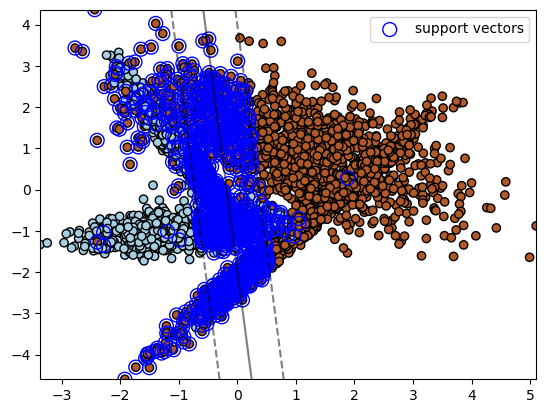

In [207]:
def plot_svm_2D(X, y, model,  plot_support=True):

    # создали сетку
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 30)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Ответы модели для сетки для отрисовки разделяющей прямой
    Z = model.decision_function(xy).reshape(XX.shape)

    plt.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

    # Отрисовали выборку
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap=plt.cm.Paired,
        edgecolors='k',
    )

    # Отрисовали опорные векторы
    if plot_support:
        plt.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            label='support vectors',
            s=100,
            linewidth=1,
            edgecolor="blue",
            facecolors='none'
        )

    plt.legend()

plot_svm_2D(X, y, model)

**Вопрос:** какие объекты выделяются как "опорные"?



**Ответ:** "опорные" объекты находятся близко к гиперсплоскости (оказывают наибольшее влияние)

В отличие от метода опорных векторов, логистическая регрессия не пытается построить разделяющую гиперплоскость с максимальным отступом, а приближает в каждой точке пространства объектов вероятность положительных ответов $p(y=+1|x)$. Попробуйте нарисовать это распределение на плоскости, не забудьте отметить на ней все объекты.

In [208]:
model = LogisticRegression(penalty='l2')
model.fit(X, y)

LogisticRegression()

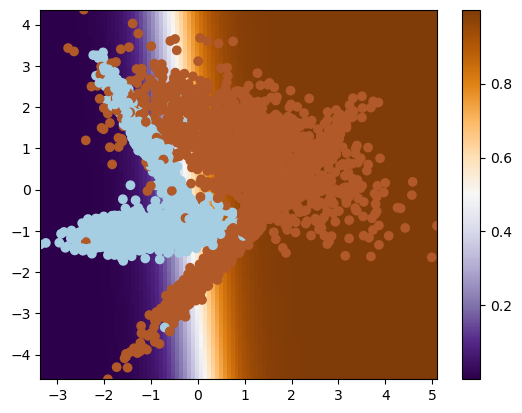

In [209]:
def plot_logreg_2D(X, y, model):

    # создали сетку
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Ответы модели для сетки для отрисовки распределения
    Z = model.predict_proba(xy)[:, 1]
    Z = Z.reshape((xx.shape[0], -1)).T

    image = plt.imshow(
        Z,
        interpolation='nearest',
        extent=(xx.min(), xx.max(), yy.min(), yy.max()),
        aspect='auto',
        origin='lower',
        cmap=plt.cm.PuOr_r
    )

    #Отрисовали выборку
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap=plt.cm.Paired
    )

    plt.colorbar(image)

plot_logreg_2D(X, y, model)

**Вопрос:** Как на картинке визуализирована область, где модель не уверена ($p(y=+1|x) = 0.5$)? Как это обосновать теоритечески?



**Ответ:** Светлая область - в ней модель дает ответ как бы 50/50 => не знает к каком классу скорее отнести объект.

#### __Задание 2. Калибровка вероятностей__ (1 балл)



Перейдём к оценке качества выдаваемых алгоритмами вероятностей. Начнём с калибровочных кривых.

Допустим, алгоритм возвращает некоторые числа от нуля до единицы. Хорошо ли они оценивают вероятность?

Хорошо откалиброванный  классификатор должен выдавать значения так, чтобы среди образцов, для которых он дал значение, близкое к $\alpha$, примерно $\alpha * 100 \%$ фактически принадлежали к положительному классу. (Например, если классификатор выдает 0.3 для некоторых, то 30% из них должны принадлежать классу 1)

Для построения калибровочной криовой используем следующий алгоритм:

Разобьем отрезок $[0, 1]$ на несколько маленьких отрезков одинаковой длины.

Рассмотрим $i$-й отрезок с границами $[a_i, b_i]$ и предсказания $p_1, p_2, \dots, p_k$, которые попали в него. Пусть им соответствуют истинные ответы $y_1, y_2, \dots, y_k$. Если алгоритм выдает корректные вероятности, то среди этих истинных ответов должно быть примерно $(a_i + b_i) / 2$ единиц. Иными словами, если нарисовать кривую, у которой по оси X отложены центры отрезков, а по оси Y — доли единичных ответов этих в отрезках, то она должна оказаться диагональной.

Ниже приведена функция, которая должна рисовать такие кривые. В ней допущено две ошибки — найдите и исправьте их.

In [210]:
def plot_calibration_curve(y_test, preds):
    bin_middle_points = []
    bin_real_ratios = []
    n_bins = 10
    for i in range(n_bins):
        l = 1.0 / n_bins * i
        r = 1.0 / n_bins * (i + 1)
        bin_middle_points.append((l + r) / 2) # 1
        bin_real_ratios.append(np.mean(y_test[(preds >= l) & (preds < r)] == 1)) # 2
    plt.figure(figsize=(15,9))
    plt.plot(bin_middle_points, bin_real_ratios)
    plt.ylim([-0.05, 1.05])
    plt.grid()

Сгенерируйте синтетические данные аналогично использованным в самом первом задании. Постройте калибровочные кривые на тестовой части для логистической регрессии и метода опорных векторов (не забудьте перевести его предсказания в $[0;1]$).

Отрисуйте калибровочную кривую идеально откалиброванной модели (диагональ)

In [211]:
# фиксируем random_state для воспроизводимости результатов
X, y = make_classification(
    n_samples=10000, n_features=10, n_informative=5, n_redundant=5, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

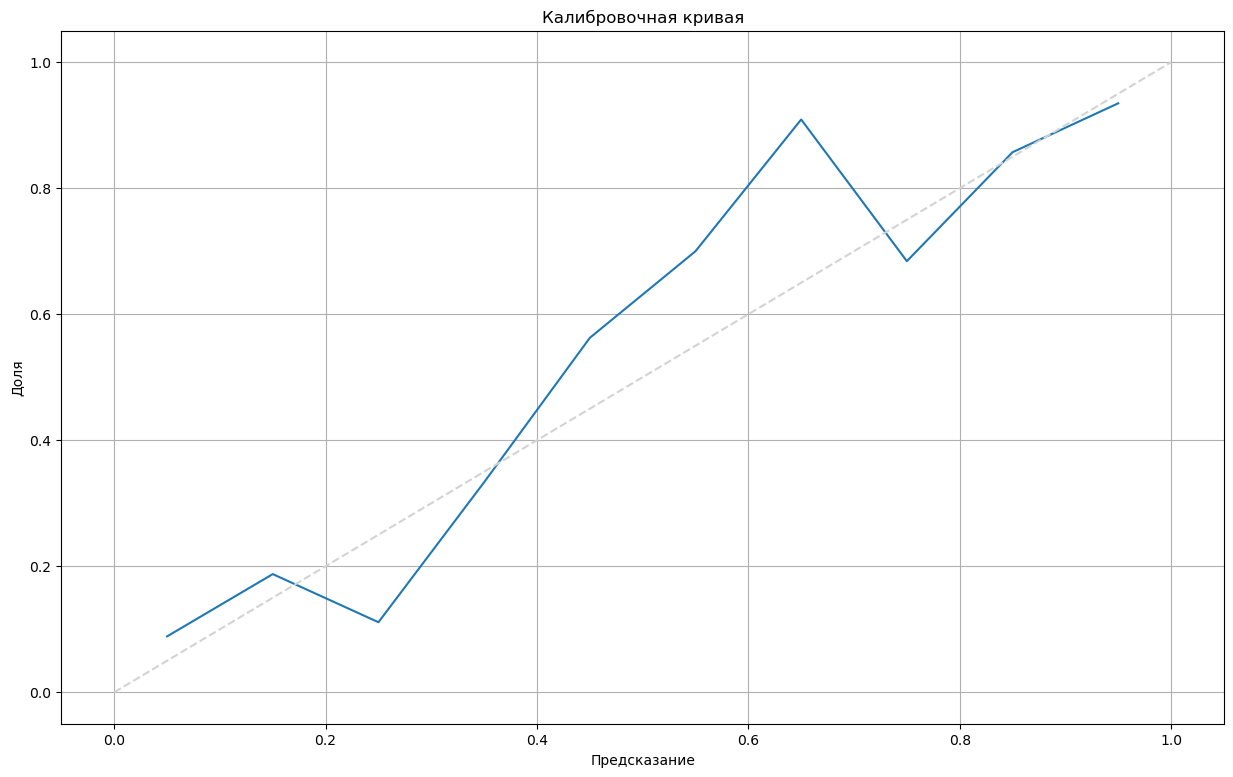

In [221]:
model = LogisticRegression(penalty='l2')
model.fit(X_train, y_train)
y_pred = model.predict_proba(X_test)[:, 1]

plot_calibration_curve(y_test, y_pred)

plt.title('Калибровочная кривая')
plt.plot([0, 1], [0, 1], linestyle='--', color='lightgray', label='Идеальная калибровка')
plt.xlabel('Предсказание')
plt.ylabel('Доля');

In [213]:
y_pred_svc

array([ 0.7427556 , -3.62677081, -1.1374355 , ..., -2.13330471,
        1.57937429,  2.12546385])

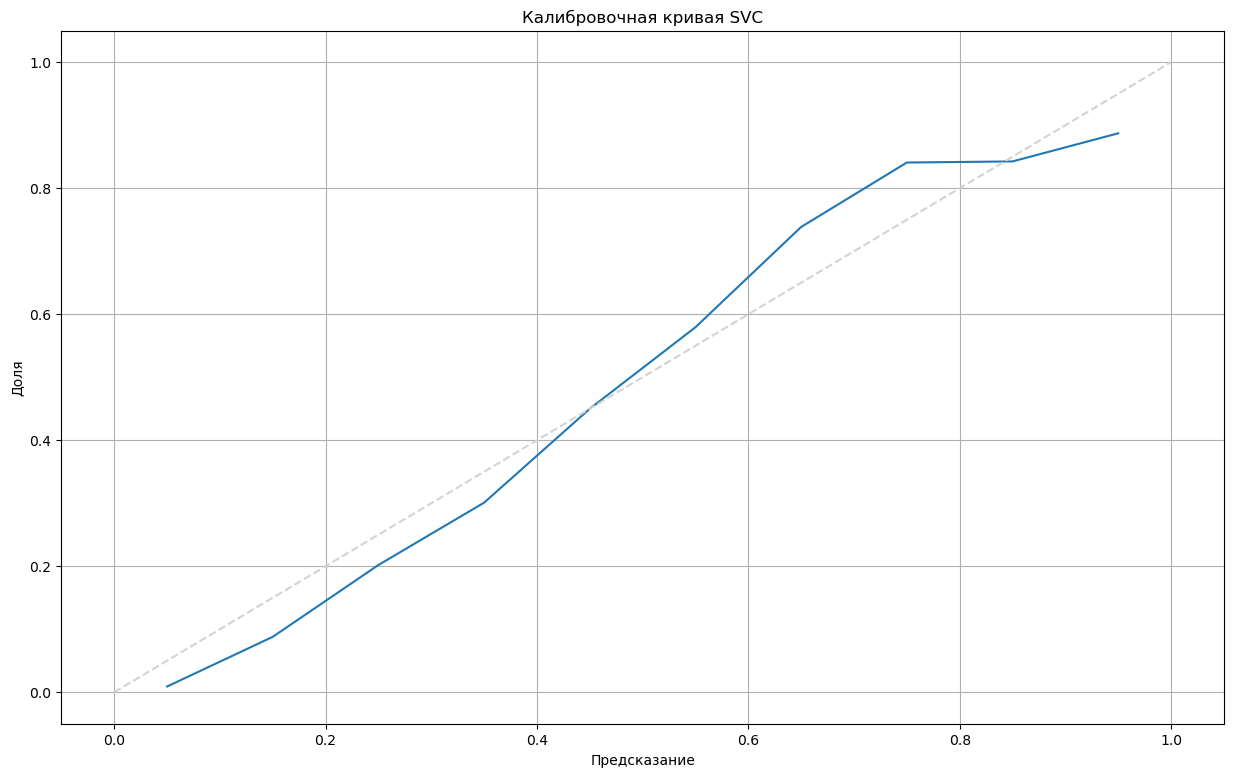

In [214]:
model = SVC(kernel='linear', max_iter=100000, C = 0.01)
model.fit(X_train, y_train)
y_pred_svc = model.decision_function(X_test)
y_pred_svc_cal = expit(y_pred_svc)

plot_calibration_curve(y_test, y_pred_svc_cal)

plt.title('Калибровочная кривая SVC')
plt.plot([0, 1], [0, 1], linestyle='--', color='lightgray', label='Идеальная калибровка')
plt.xlabel('Предсказание')
plt.ylabel('Доля');

**Вопрос**: хорошо ли откалиброваны кривые для SVM, логистической регрессии? Подумайте, как это следует из вида кривой

**Ответ:** Да, калибровка удовлетворительная (близка к диагональной линии)

Из формальных способов в этом убедиться есть знакомый вам LogLoss, который напрямую оценивает вероятности,
$$\text{LogLoss} = -\frac{1}{N}\sum_{i} \sum_{k \in {0. 1}}\log p_k[y_i = k]$$
а так же BrierScore, который подсчитывает отклонение между получившейся вероятностью и реальным значением таргета.
$$\text{BrierScore} = \frac{1}{N}\sum_{i} (p_i - y_i)^2$$
Посмотрите на них тоже и сделайте вывод

In [215]:
def log_loss(y_true, y_prob):
    
  y_true = np.array(y_true)
  y_prob = np.array(y_prob)
  epsilon = 1e-15  
  y_prob = np.clip(y_prob, epsilon, 1 - epsilon) 
  log_loss = -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
  return log_loss

def brier_score(y_true, y_prob):
  y_true = np.array(y_true)
  y_prob = np.array(y_prob)
  return np.mean((y_prob - y_true)**2)

logloss = log_loss(y_test, y_pred)
brier = brier_score(y_test, y_pred)

print(f"LogLoss LR: {logloss}")
print(f"BrierScore LR: {brier}")

print()

logloss = log_loss(y_test, y_pred_svc)
brier = brier_score(y_test, y_pred_svc)
print(f"LogLoss SVC: {logloss}")
print(f"BrierScore SVC: {brier}")

LogLoss LR: 0.4858547138605954
BrierScore LR: 0.15858324761523218

LogLoss SVC: 5.173861078319379
BrierScore SVC: 1.7837409799832689


Изучите распределение ответов классификаторов при помощи гистограмм

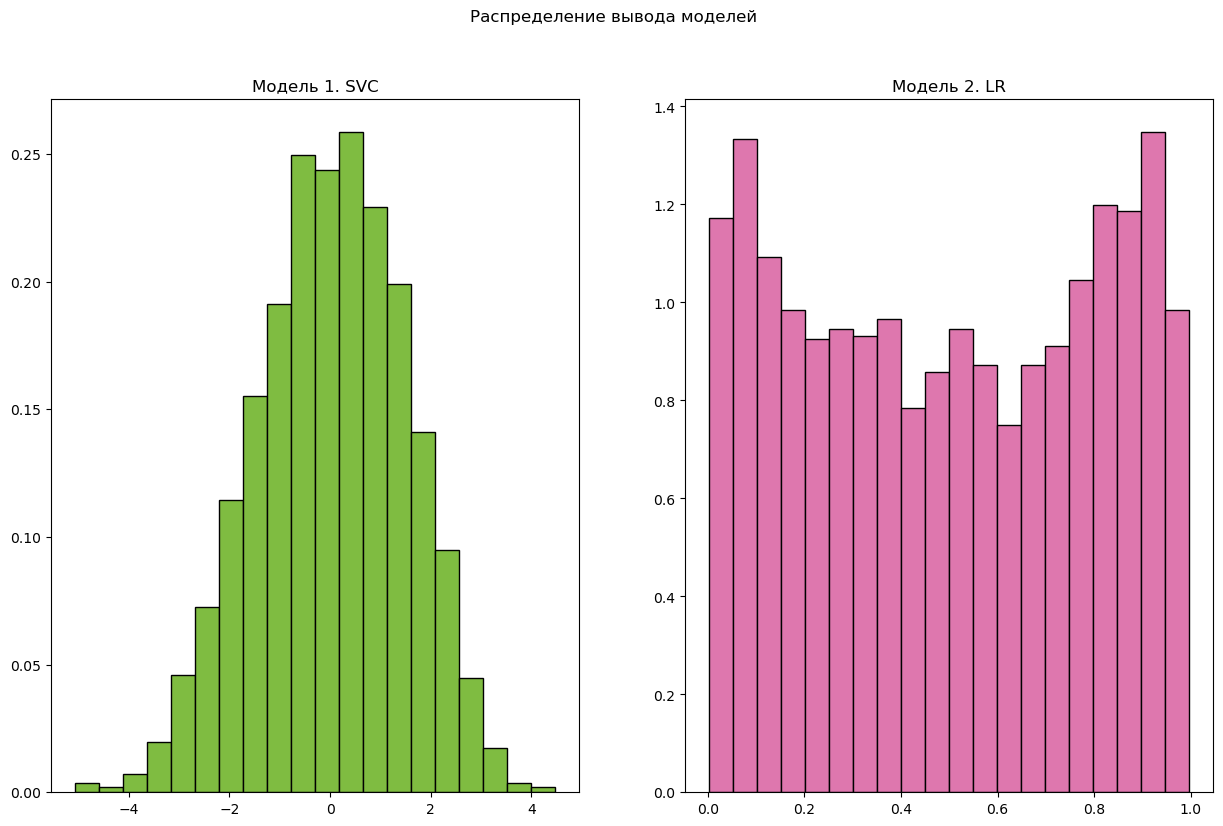

In [216]:
predictions_svc = np.array(y_pred_svc)
predictions_lr = np.array(y_pred)

num_bins = 20
colors = plt.get_cmap('PiYG_r')  
labels = ['Модель 1. SVС', 'Модель 2. LR']

chart_size = (15, 9)
display_charts = plt.figure(figsize=chart_size)
chart_svc = display_charts.add_subplot(1, 2, 1)
chart_lr = display_charts.add_subplot(1, 2, 2)

chart_svc.hist(predictions_svc, bins=num_bins, color=colors(0.2), density=True, edgecolor='black')
chart_lr.hist(predictions_lr, bins=num_bins, color=colors(0.8), density=True, edgecolor='black')

chart_svc.set_title(labels[0])
chart_lr.set_title(labels[1])
display_charts.suptitle('Распределение вывода моделей')

plt.show()

**Вопрос:** Чем они различаются? Чем вы можете объяснить это?

**Ответ:** SVM значительно реже может с уверенностью отнести объект к тому или иному классу, поэтому на границах плотность распределения ниже (у лог регрессии все более равномерно, значит модель может выдавать более однозначные прогнозы)

Воспользуйтесь `CalibratedClassifierCV` из `sklearn` для калибровки вероятностей метода опорных векторов на обучении и постройте с его помощью  предсказания для тестовой выборки.

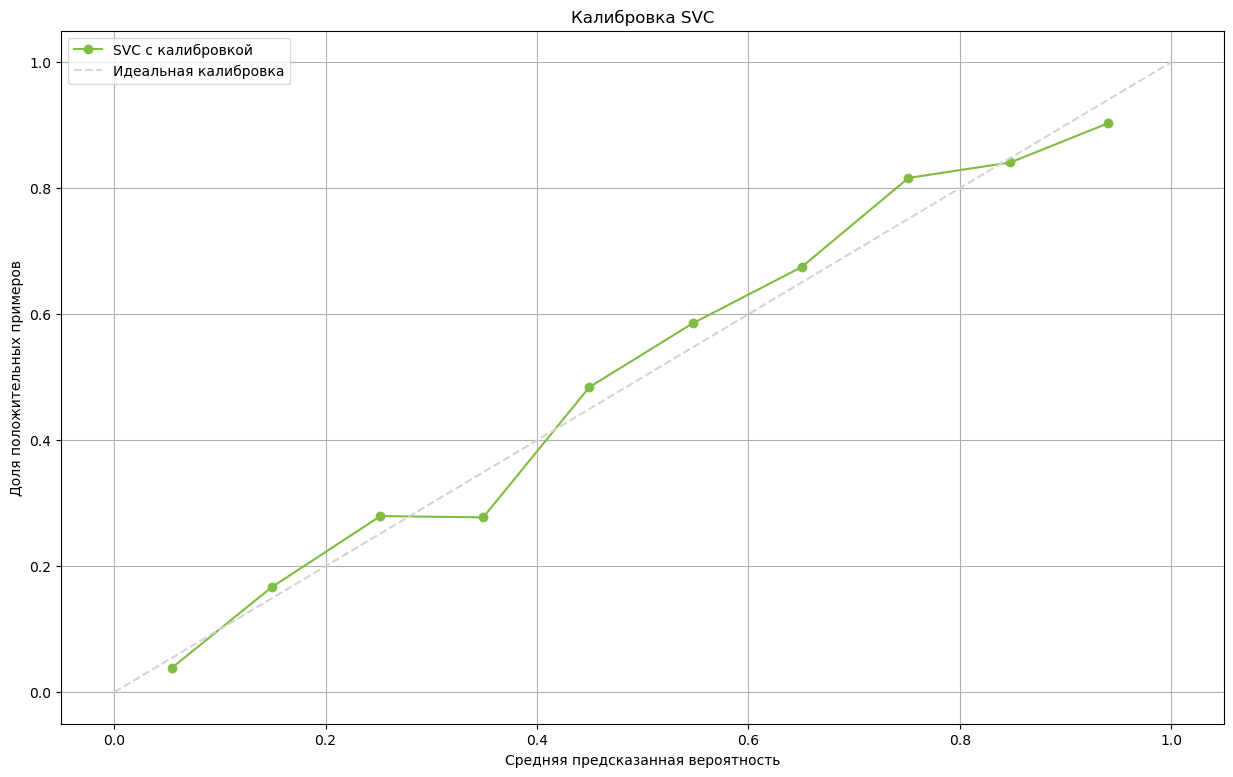

In [217]:
model_svc = CalibratedClassifierCV(LinearSVC(max_iter=10000, C=0.01))

model_svc.fit(X_train, y_train)
predicted_probs = model_svc.predict_proba(X_test)[:, 1]

#plot_calibration_curve(y_test, predicted_probs)

prob_true, prob_pred = calibration_curve(y_test, predicted_probs, n_bins=10)
plt.figure(figsize=(15, 9))
plt.plot(prob_pred, prob_true, marker='o', label='SVC с калибровкой', color=colors(0.2))
plt.plot([0, 1], [0, 1], linestyle='--', color='lightgray', label='Идеальная калибровка')
plt.title('Калибровка SVC')
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля положительных примеров')
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Улучшились ли калибровочная кривая и качество калибровки?

**Ответ:** Да, качество калибровки визуально стало лучше

##### __Бонус: Авторское решение__ (0.5 балла)

Реализуйте свою функцию для калибровки вероятностей, используя любой из известных подходов. Кратко опишите ваш подход и продемонстрируйте результаты. Ключевые слова для вдохновения: `Platt`, `Isotonic`.

Попытка 1:

In [222]:
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

probabilities = model.predict_proba(X_test)[:, 1]

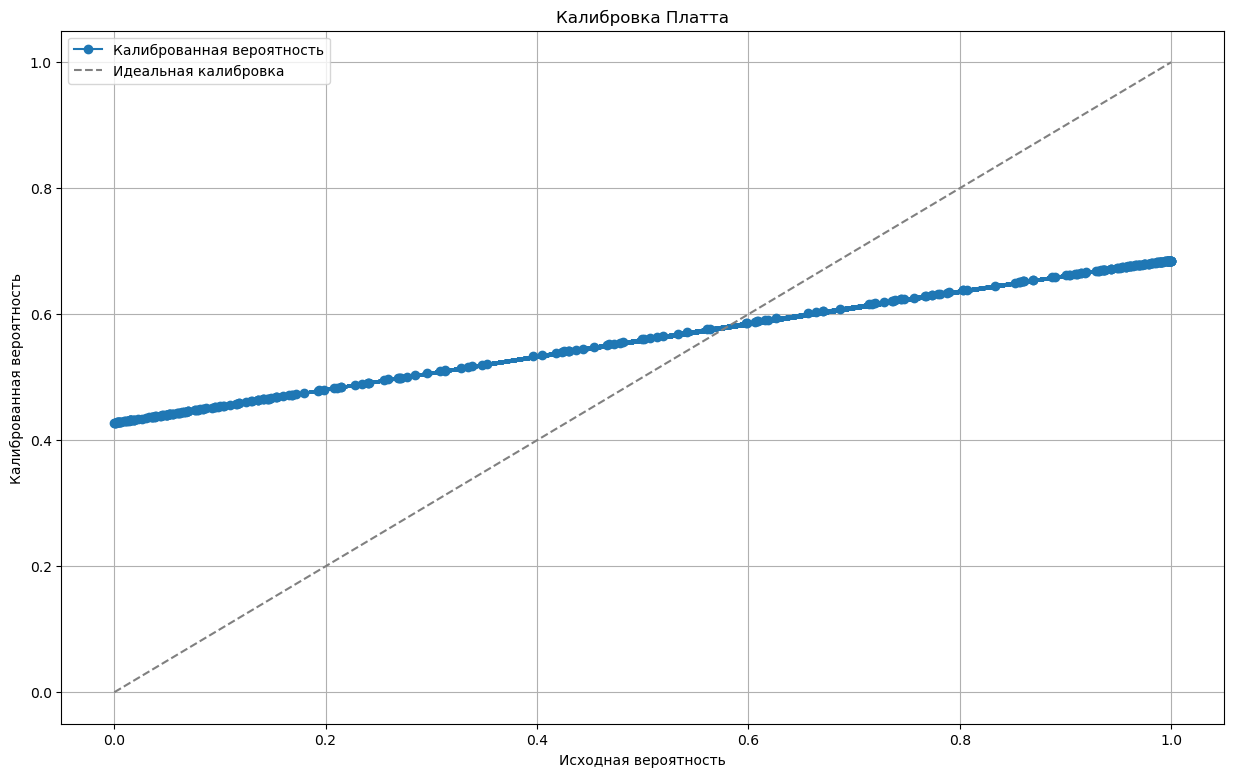

In [223]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def platt_calibration(probabilities, labels, iterations=1000, learning_rate=0.01):
    """
    Упрощенная калибровка Платта с использованием градиентного спуска.
    """
    n = len(probabilities)
    A = 0.0
    B = 0.0

    for _ in range(iterations):
        dA = 0.0
        dB = 0.0
        for i in range(n):
            f = sigmoid(A * probabilities[i] + B)
            dA += (labels[i] - f) * probabilities[i]
            dB += (labels[i] - f)
        A += learning_rate * dA / n
        B += learning_rate * dB / n

    def calibrated_probability(p):
        return sigmoid(A * p + B)

    return calibrated_probability


calibrated_prob_func = platt_calibration(probabilities, y_test)
calibrated_probabilities = np.array([calibrated_prob_func(p) for p in probabilities])

plt.figure(figsize=(15, 9))
plt.plot(probabilities, calibrated_probabilities, marker='o', linestyle='-', label='Калиброванная вероятность')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Идеальная калибровка')
plt.xlabel("Исходная вероятность")
plt.ylabel("Калиброванная вероятность")
plt.title("Калибровка Платта")
plt.legend()
plt.grid(True)
plt.show()

Попытка 2 (готовые функции):

In [224]:
# метода Платта
platt_calibrated = CalibratedClassifierCV(classifier, method='sigmoid', cv='prefit')
platt_calibrated.fit(X_test, y_test)
platt_probs = platt_calibrated.predict_proba(X_test)[:, 1]
prob_true_platt, prob_pred_platt = calibration_curve(y_test, platt_probs, n_bins=10)

# Изотонической регрессии
isotonic_calibrated = CalibratedClassifierCV(classifier, method='isotonic', cv='prefit')
isotonic_calibrated.fit(X_test, y_test)
isotonic_probs = isotonic_calibrated.predict_proba(X_test)[:, 1]
prob_true_isotonic, prob_pred_isotonic = calibration_curve(y_test, isotonic_probs, n_bins=10)

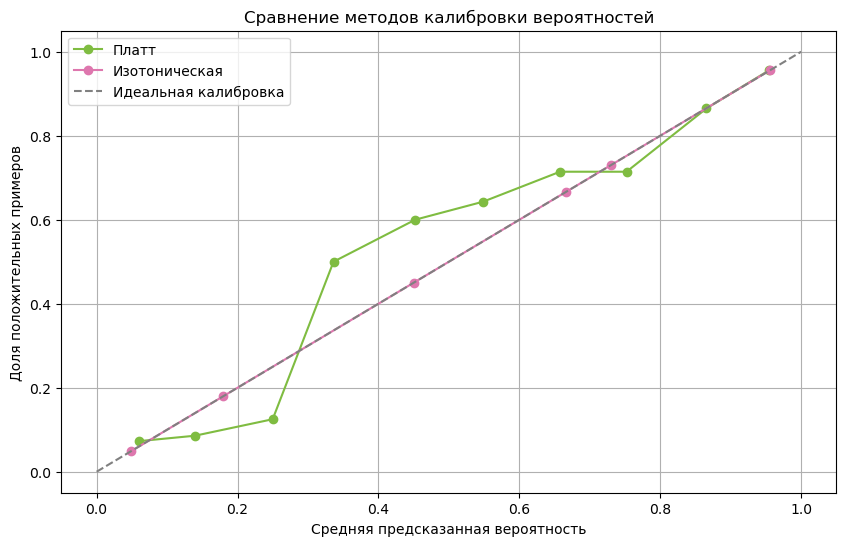

In [225]:
plt.figure(figsize=(10, 6))
plt.plot(prob_pred_platt, prob_true_platt, marker='o', label='Платт', color=colors(0.2))
plt.plot(prob_pred_isotonic, prob_true_isotonic, marker='o', label='Изотоническая', color=colors(0.8))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Идеальная калибровка')

# Настройка графика
plt.title('Сравнение методов калибровки вероятностей')
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля положительных примеров')
plt.legend()
plt.grid()
plt.show()

# Часть 2. Обработка категориальных переменных (4 балла + 1.5 бонус)

Как мы знаем, перекодировать категориальную переменную в список чисел (к примеру 1, 2, 3, ..., n) плохо, поскольку это бы задало на множестве ее значений некоторый порядок, не имеющий смысла.

В этой части мы рассмотрим два основных способа обработки категориальных значений:
- One-hot-кодирование
- Счётчики (CTR, mean-target кодирование, ...) — каждый категориальный признак заменяется на среднее значение целевой переменной по всем объектам, имеющим одинаковое значение в этом признаке.

Начнём с one-hot-кодирования. Допустим наш категориальный признак $f_j(x)$ принимает значения из множества $C=\{c_1, \dots, c_m\}$. Заменим его на $m$ бинарных признаков $b_1(x), \dots, b_m(x)$, каждый из которых является индикатором одного из возможных категориальных значений:
$$
b_i(x) = [f_j(x) = c_i]
$$

#### __Подготовка данных__

*(бесценный шаг)*

Разберем датасет [покупок велосипедов](https://www.kaggle.com/datasets/heeraldedhia/bike-buyers/): даны признаки покупателя, требуется предсказать, купит ли он/она велосипед



Замените пропуски в категориальных переменных на новую категорию (`'undefined'`)

Разделите признаки на 2 таблицы: категориальные и числовые признаки

In [226]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [227]:
import kagglehub

path = kagglehub.dataset_download("heeraldedhia/bike-buyers") +  "/bike_buyers.csv"

In [228]:
# Прочитаем датасет
df = pd.read_csv(path)
df.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes


In [229]:
df.dtypes

ID                    int64
Marital Status       object
Gender               object
Income              float64
Children            float64
Education            object
Occupation           object
Home Owner           object
Cars                float64
Commute Distance     object
Region               object
Age                 float64
Purchased Bike       object
dtype: object

In [230]:
# Заменим пропуски категориальных переменных
cats = df.select_dtypes('object').columns
df[cats] = df[cats].fillna('undefined')
df

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,undefined,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,23731,Married,Male,60000.0,2.0,High School,Professional,Yes,2.0,2-5 Miles,North America,54.0,Yes
996,28672,Single,Male,70000.0,4.0,Graduate Degree,Professional,Yes,0.0,2-5 Miles,North America,35.0,Yes
997,11809,Married,undefined,60000.0,2.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,North America,38.0,Yes
998,19664,Single,Male,100000.0,3.0,Bachelors,Management,No,3.0,1-2 Miles,North America,38.0,No


In [231]:
# Уберем колонку ID. Она все равно никакой инфы не несет

df.drop(columns=['ID'], inplace=True)

In [232]:
# Отделим X и y

X = df.drop(columns=['Purchased Bike'])
y = df['Purchased Bike']

# Разделим на категориальные признаки и числовые
X_numerical = X.select_dtypes(['float64'])
X_categorical =  X.select_dtypes(['object'])

В начале поработаем только с категориальными признаками

In [233]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_categorical, y, test_size=0.25, random_state=777, stratify=y)

In [234]:
X_categorical

,Marital Status,Gender,Education,Occupation,Home Owner,Commute Distance,Region
0,Married,Female,Bachelors,Skilled Manual,Yes,0-1 Miles,Europe
1,Married,Male,Partial College,Clerical,Yes,0-1 Miles,Europe
2,Married,Male,Partial College,Professional,No,2-5 Miles,Europe
3,Single,undefined,Bachelors,Professional,Yes,5-10 Miles,Pacific
4,Single,Male,Bachelors,Clerical,No,0-1 Miles,Europe
...,...,...,...,...,...,...,...
995,Married,Male,High School,Professional,Yes,2-5 Miles,North America
996,Single,Male,Graduate Degree,Professional,Yes,2-5 Miles,North America
997,Married,undefined,Bachelors,Skilled Manual,Yes,0-1 Miles,North America
998,Single,Male,Bachelors,Management,No,1-2 Miles,North America


#### __Задание 3. OrdinalEncoder__  (0.5 балла)

Закодируйте категориальные признаки с помощью `OrdinalEncoder`. Посчитайте качество (в этом задании будем работать c __`AUC-PR`__) при применении логистической регрессии. Замерьте время, потребовавшееся на обучение модели, с учетом кодирования признаков.

In [235]:
y_test_num = np.where(np.array(y_test) == 'Yes', 1, 0)
y_test_num

array([1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1])

PR value: 0.5789437602089755
Время: 0.01492762565612793


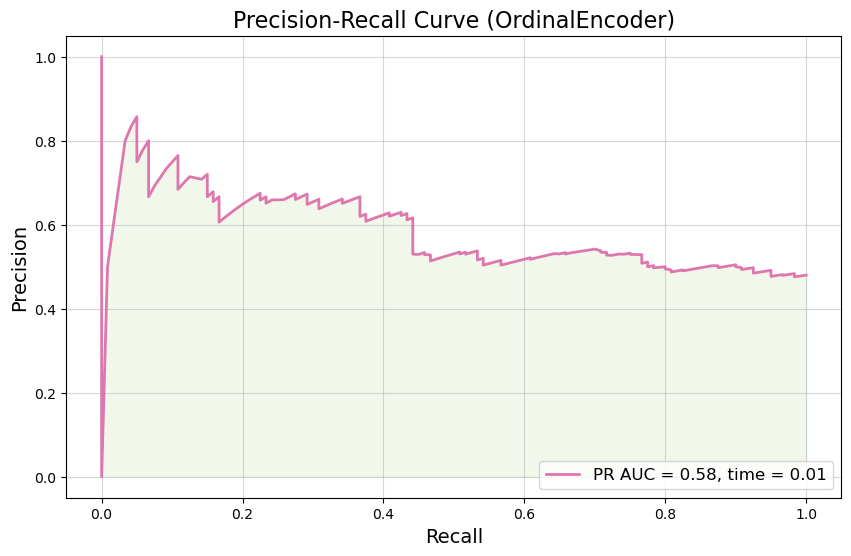

In [236]:
import time
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import auc

encoder = OrdinalEncoder()

start = time.time()

X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)
model = LogisticRegression()
model.fit(X_train_encoded, y_train)

end = time.time()

time_delta = end - start

y_pred = model.predict_proba(X_test_encoded)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test_num, y_pred)
pr_auc = auc(recall, precision)

print(f'PR value: {pr_auc}')
print(f'Время: {time_delta}')

plt.figure(figsize=(10, 6))
plt.title('Precision-Recall Curve (OrdinalEncoder)', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.plot(recall, precision, color=colors(0.8), lw=2, label=f'PR AUC = {pr_auc:.2f}, time = {time_delta:.2f}')
plt.fill_between(recall, precision, alpha=0.1, color=colors(0.2))

plt.grid(alpha=0.5)
plt.legend(loc='lower right', fontsize=12)

plt.show()

#### __Задание 4. One-Hot Encoding__ (0.5 балла)



Закодируйте все категориальные признаки с помощью one-hot-кодирования. Обучите логистическую регрессию и посмотрите, как изменилось качество модели (в сравнении с тем, что было до кодирования). Измерьте время, потребовавшееся на кодирование категориальных признаков и обучение модели.

PR value: 0.6618645231989089
Время: 0.027910232543945312


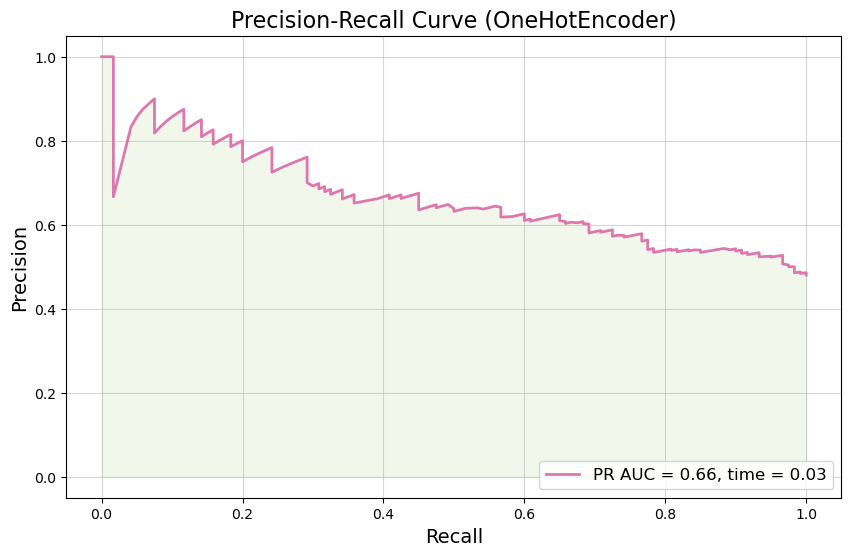

In [237]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

start = time.time()

X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)
model = LogisticRegression()
model.fit(X_train_encoded, y_train)

end = time.time()

time_delta = end - start

y_pred = model.predict_proba(X_test_encoded)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test_num, y_pred)
pr_auc = auc(recall, precision)

print(f'PR value: {pr_auc}')
print(f'Время: {time_delta}')

plt.figure(figsize=(10, 6))
plt.title('Precision-Recall Curve (OneHotEncoder)', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.plot(recall, precision, color=colors(0.8), lw=2, label=f'PR AUC = {pr_auc:.2f}, time = {time_delta:.2f}')
plt.fill_between(recall, precision, alpha=0.1, color=colors(0.2))

plt.grid(alpha=0.5)
plt.legend(loc='lower right', fontsize=12)

plt.show()

Как можно заметить, one-hot-кодирование может сильно увеличивать количество признаков. Это сказывается на объеме необходимой памяти, особенно, если некоторый признак имеет большое количество значений.


#### __Задание 5. Mean-target Encoding__ (1 балл)

> Проблемы разрастания числа признаков можно избежать в другом способе кодирования категориальных признаков — mean-target encoding (для простоты будем называть это __счётчиками__). Сравним эффективность методов в рамках нашей маркетинговой задачи.

> Основная идея в том, что важны не сами категории, а значения целевой переменной, которые имеют объекты этой категории. Каждый категориальный признак мы заменим средним значением целевой переменной по всем объектам этой же категории:

$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1]}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)]}
$$

Закодируйте категориальные переменные с помощью счётчиков (ровно так, как описано выше, без каких-либо хитростей). Обучите логистическую регрессию и посмотрите на качество модели на тестовом множестве.

Сравните время обучения с предыдущими экспериментами (с учетом кодирования признаков).

In [238]:
y_train 

345    Yes
540     No
110    Yes
902     No
15     Yes
      ... 
483     No
375     No
968     No
756    Yes
883    Yes
Name: Purchased Bike, Length: 750, dtype: object

In [239]:
y_train_num = y_train.map({'Yes': 1, 'No': 0})
X_train['true'] = y_train_num

PR value: 0.670121620546432
Время: 0.032889604568481445


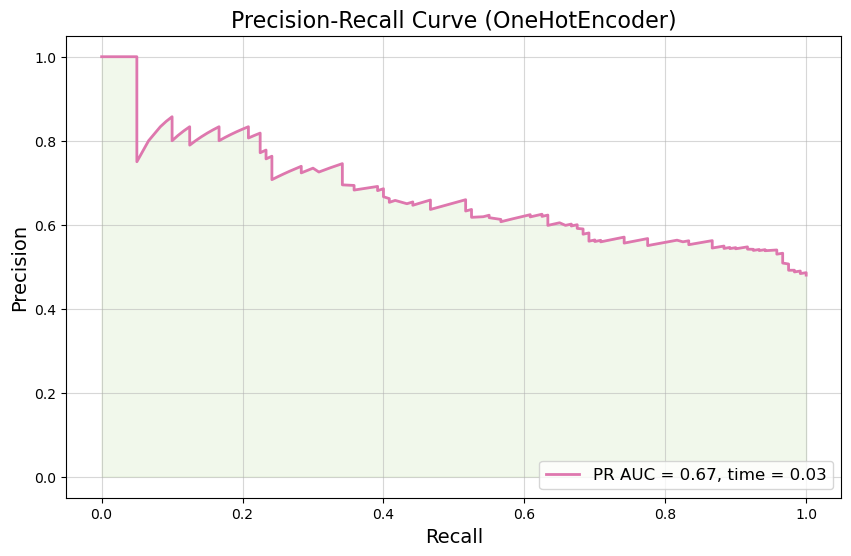

In [253]:
start = time.time()

train_encoded = X_train.copy()
test_encoded = X_test.copy()

for column in X_train.select_dtypes('object').columns:
    frequency = (
        X_train.groupby(column)['true']
        .transform(lambda x: (x == 1).sum() / (len(x) + 1))
    )
    train_encoded[column] = frequency
    test_encoded[column] = test_encoded[column].map(X_train.groupby(column)['true'].mean())

train_encoded_1 = train_encoded.drop(columns=['true'])
log_reg_model = LogisticRegression(penalty='l2', C=1e9)
log_reg_model.fit(train_encoded_1, y_train_num)

end = time.time()

time_delta = end - start

y_pred = log_reg_model.predict_proba(test_encoded)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test_num, y_pred)
pr_auc = auc(recall, precision)

print(f'PR value: {pr_auc}')
print(f'Время: {time_delta}')

plt.figure(figsize=(10, 6))
plt.title('Precision-Recall Curve (OneHotEncoder)', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.plot(recall, precision, color=colors(0.8), lw=2, label=f'PR AUC = {pr_auc:.2f}, time = {time_delta:.2f}')
plt.fill_between(recall, precision, alpha=0.1, color=colors(0.2))

plt.grid(alpha=0.5)
plt.legend(loc='lower right', fontsize=12)

plt.show()

##### __Бонус: Эффективная реализация (1 балл)__

Здесь и далее реализуйте вычисление счетчиков с помощью трансформера (наследуйтесь от классов `BaseEstimator, TransformerMixin` из `sklearn.base`). Обратите внимание, что все вычисления должны быть векторизованными, трансформер не должен модифицировать передаваемую ему выборку inplace, а все необходимые статистики нужно считать только по обучающей выборке в методе `fit`. Ваш трансформер должен принимать при инициализации список из категориальных признаков и изменять только их.

In [267]:
from sklearn.base import BaseEstimator, TransformerMixin

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, categorical_features):
        self.categorical_features = categorical_features
        self.frequency_map = {}

    def fit(self, X, y):
        # Вычисляем частоту положительных значений для каждого уникального значения в указанных столбцах
        X_tr = X.copy()
        X_tr['true'] = y
        for column in self.categorical_features:
            self.frequency_map[column] = (
                X_tr.groupby(column)['true']  # Используем имя целевой переменной
                .transform(lambda x: (x == 1).sum() / (len(x) + 1))  
            )
        return self

    def transform(self, X):
        X_encoded = X.copy()
        for column in self.categorical_features:
            # Заменяем категориальные значения на вычисленные частоты
            X_encoded[column] = X_encoded[column].map(self.frequency_map[column]).fillna(0)
        return X_encoded

PR value: 0.74
Время: 0.013857364654541016


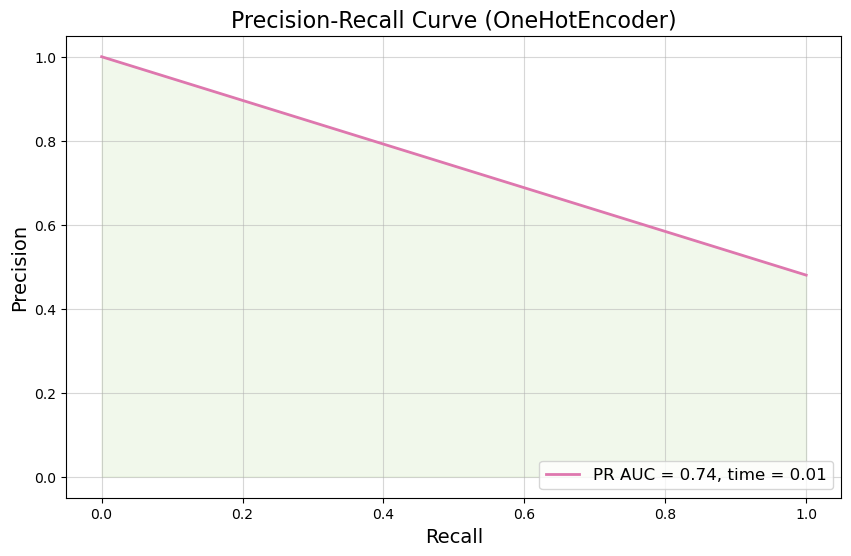

In [270]:
encoder = FrequencyEncoder(X_train.select_dtypes('object').columns)
encoder.fit(X_train.drop(columns=['true']), y_train_num)

start = time.time()

X_train_encoded = encoder.transform(X_train.drop(columns=['true']))
X_test_encoded = encoder.transform(X_test)
model = LogisticRegression()
model.fit(X_train_encoded, y_train_num)

end = time.time()

time_delta = end - start

y_pred = model.predict_proba(X_test_encoded)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test_num, y_pred)
pr_auc = auc(recall, precision)

print(f'PR value: {pr_auc}')
print(f'Время: {time_delta}')

plt.figure(figsize=(10, 6))
plt.title('Precision-Recall Curve (OneHotEncoder)', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.plot(recall, precision, color=colors(0.8), lw=2, label=f'PR AUC = {pr_auc:.2f}, time = {time_delta:.2f}')
plt.fill_between(recall, precision, alpha=0.1, color=colors(0.2))

plt.grid(alpha=0.5)
plt.legend(loc='lower right', fontsize=12)

plt.show()

_______

__Методы борьбы с переобучением счетчиков__


Отметим, что mean-target encoding признаки сами по себе являются классификаторами и, обучаясь на них, мы допускаем "утечку" целевой переменной в признаки. Это ведёт к __переобучению__, поэтому считать такие признаки необходимо таким образом, чтобы при вычислении для конкретного объекта его __целевая метка не использовалась__.

Это можно делать следующими способами:
1. Вычислять значение счётчика по всем объектам расположенным выше в датасете (например, если у нас выборка отсортирована по времени).
2. Вычислять по фолдам, то есть делить выборку на некоторое количество частей и подсчитывать значение признаков по всем фолдам кроме текущего (как делается в кросс-валидации).
3. Внесение некоторого шума в посчитанные признаки.

#### __Задание 6. Пошумим__  (0.5 балла)

Реализуйте корректное вычисление счётчиков самым простым способом — добавление шума к значениям.  При этом постарайтесь найти баланс между борьбой с переобучением и сохранением полезности признаков. Снова обучите логистическую регрессию, оцените качество.

PR value: 0.6734711346730825
Время: 0.04883432388305664


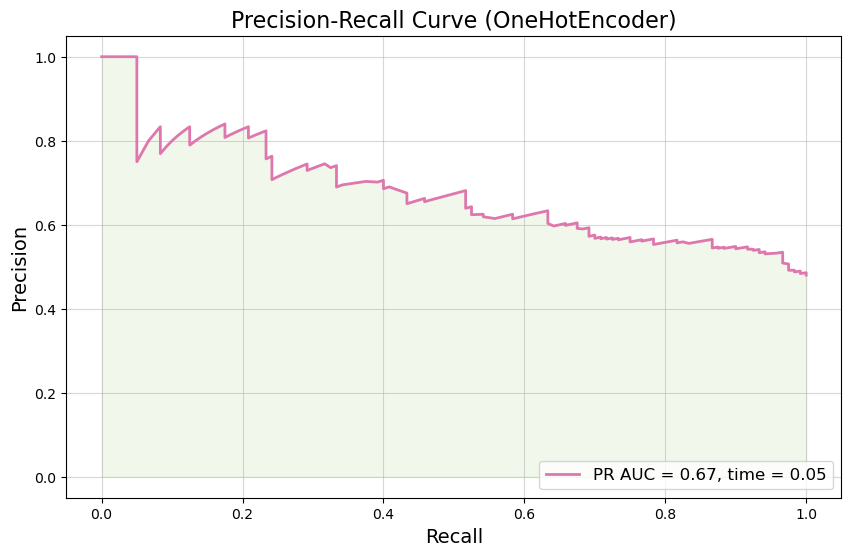

In [275]:
start = time.time()

train_encoded = X_train.copy()
test_encoded = X_test.copy()

for column in X_train.select_dtypes('object').columns:
    frequency = (
        X_train.groupby(column)['true']
        .transform(lambda x: (x == 1).sum() / (len(x) + np.random.randn()))
    )
    train_encoded[column] = frequency
    test_encoded[column] = test_encoded[column].map(X_train.groupby(column)['true'].mean())

train_encoded_1 = train_encoded.drop(columns=['true'])
log_reg_model = LogisticRegression(penalty='l2', C=1e9)
log_reg_model.fit(train_encoded_1, y_train_num)

end = time.time()

time_delta = end - start

y_pred = log_reg_model.predict_proba(test_encoded)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test_num, y_pred)
pr_auc = auc(recall, precision)

print(f'PR value: {pr_auc}')
print(f'Время: {time_delta}')

plt.figure(figsize=(10, 6))
plt.title('Precision-Recall Curve (OneHotEncoder)', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.plot(recall, precision, color=colors(0.8), lw=2, label=f'PR AUC = {pr_auc:.2f}, time = {time_delta:.2f}')
plt.fill_between(recall, precision, alpha=0.1, color=colors(0.2))

plt.grid(alpha=0.5)
plt.legend(loc='lower right', fontsize=12)

plt.show()

**Вопрос:** Сделайте выводы. Помогло ли добавление шума? Почему?

**Ответ:** Добавление шума улучшило качество (хоть и не слишком значительно), поскольку позволило уменьшить переобучение

##### __Бонус: другой подход__ (0.5 балла)

Посчитайте корректные счётчики первым или вторым способов из описанных выше (не забудьте добавить и шум).




In [ ]:
# your code here

#### __Задание 7. Сглаживание счетчиков__  (1 балл)

> Теперь ответим на следующий вопрос: что будет, если некоторая категория встречается в выборке всего несколько раз? По этой причине производится сглаживание счётчиков. Например, на практике хорошие результаты показывает использование сглаживания средним по всей выборке:
$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1] + C \times \text{global_mean}}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)] + C}
$$
где $\text{global_mean}$ — доля объектов положительного класса в выборке, $C$ — параметр, определяющий степень сглаживания (можно использовать 10 или подобрать для каждого признака свой). Идея в том, что мы "разбавляем" среднее значение по категории глобальным средним значением. И тем меньше, чем большее количество объектов этой категории встречается в выборке.

> Вместо среднего значения целевой переменной для сглаживания можно использовать любое другое значение от 0 до 1 (этот параметр иногда называют $prior$). Можно сделать несколько признаков с разными значениями параметра. На практике в задачах бинарной классификации полезными бывают даже отрицательные значения!

Добавьте сглаживание, описанное выше и повторите эксперименты. Подберите $C$, чтобы качество было лучше, чем при использовании One-Hot-Encoding


PR value: 0.6755715778037428
Время: 0.04285573959350586


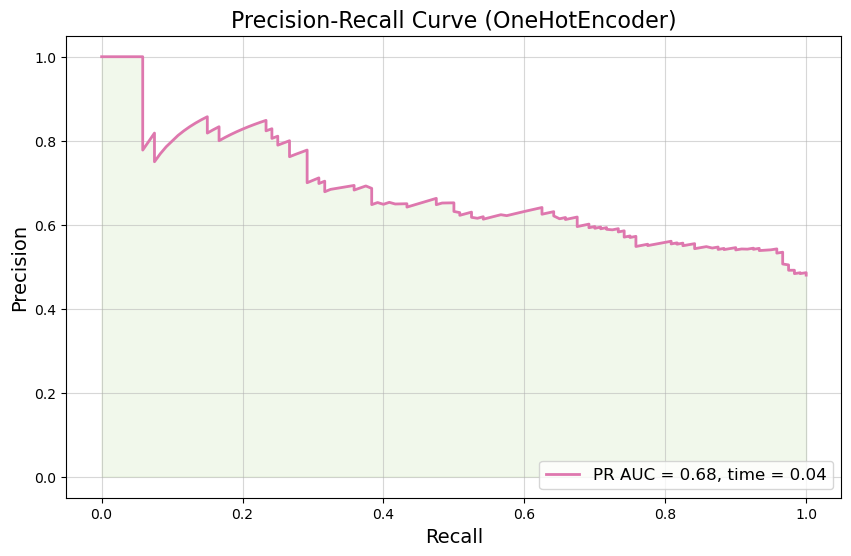

In [276]:
start = time.time()

train_encoded = X_train.copy()
test_encoded = X_test.copy()

for column in X_train.select_dtypes('object').columns:
    frequency = (
        X_train.groupby(column)['true']
        .transform(lambda x: ((x == 1).sum() + 5 * np.mean(y_train_num)) / (len(x) + 5))
    )
    train_encoded[column] = frequency
    test_encoded[column] = test_encoded[column].map(X_train.groupby(column)['true'].mean())

train_encoded_1 = train_encoded.drop(columns=['true'])
log_reg_model = LogisticRegression(penalty='l2', C=1e9)
log_reg_model.fit(train_encoded_1, y_train_num)

end = time.time()

time_delta = end - start

y_pred = log_reg_model.predict_proba(test_encoded)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test_num, y_pred)
pr_auc = auc(recall, precision)

print(f'PR value: {pr_auc}')
print(f'Время: {time_delta}')

plt.figure(figsize=(10, 6))
plt.title('Precision-Recall Curve (OneHotEncoder)', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.plot(recall, precision, color=colors(0.8), lw=2, label=f'PR AUC = {pr_auc:.2f}, time = {time_delta:.2f}')
plt.fill_between(recall, precision, alpha=0.1, color=colors(0.2))

plt.grid(alpha=0.5)
plt.legend(loc='lower right', fontsize=12)

plt.show()

#### **Задание 8. Числовые или категориальные?**  (0.5 балла)

Теперь добавим числовые признаки к счётчикам (тем, которые дали наибольший прирост качества).


Проверьте их на наличие выбросов и заполните пропуски средним или медианой, подумайте, что лучше в условиях наших данных



In [287]:
X_numerical

,Income,Children,Cars,Age
0,40000.0,1.0,0.0,42.0
1,30000.0,3.0,1.0,43.0
2,80000.0,5.0,2.0,60.0
3,70000.0,0.0,1.0,41.0
4,30000.0,0.0,0.0,36.0
...,...,...,...,...
995,60000.0,2.0,2.0,54.0
996,70000.0,4.0,0.0,35.0
997,60000.0,2.0,0.0,38.0
998,100000.0,3.0,3.0,38.0


In [284]:
import warnings
warnings.filterwarnings('ignore')

In [288]:
def preprocess_numerical_features(X):
    for column in X.columns:
        # Заполнение пропусков средним значением
        mean_value = X[column].mean()
        X[column].fillna(mean_value, inplace=True)
        
        # Вычисляем границы для выбросов
        Q1 = X[column].quantile(0.25)
        Q3 = X[column].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Удаление выбросов
        X = X[(X[column] >= lower_bound) & (X[column] <= upper_bound)]
    return X

In [289]:
preprocess_numerical_features(X_numerical) # выбросов видимо нет, поскольку осталось то же число строк

,Income,Children,Cars,Age
0,40000.0,1.0,0.0,42.0
1,30000.0,3.0,1.0,43.0
2,80000.0,5.0,2.0,60.0
3,70000.0,0.0,1.0,41.0
4,30000.0,0.0,0.0,36.0
...,...,...,...,...
995,60000.0,2.0,2.0,54.0
996,70000.0,4.0,0.0,35.0
997,60000.0,2.0,0.0,38.0
998,100000.0,3.0,3.0,38.0


In [291]:
X_numerical.isnull().sum()

Income      0
Children    0
Cars        0
Age         0
dtype: int64

 Сейчас для числовых признаков мы ищем линейную зависимость, что в общем случае  может быть неверной гипотезой. Тем не менее, у этих признаков есть довольно много уникальных значений (сколько?), поэтому применять к ним one-hot кодирование может оказаться излишним. Попробуйте закодировать эти признаки с помощью счетчиков. Стало ли лучше?

In [292]:
X_numerical.nunique()

Income      14
Children     7
Cars         6
Age         52
dtype: int64

In [299]:
def fill_missing_values(X, categorical_features, numerical_features):
    for column in categorical_features:
        X[column].fillna('undefined', inplace=True)
    
    for column in numerical_features:
        mean_value = X[column].mean()
        X[column].fillna(mean_value, inplace=True)
    
    return X

X = fill_missing_values(X, X.select_dtypes('object'), X.select_dtypes('float64'))

In [300]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=777, stratify=y)

In [301]:
num = {'Yes':1, 'No':0}
y_train_num, y_test_num = y_train.map(num), y_test.map(num)

PR value: 0.6816596244248991
Время: 0.09965181350708008


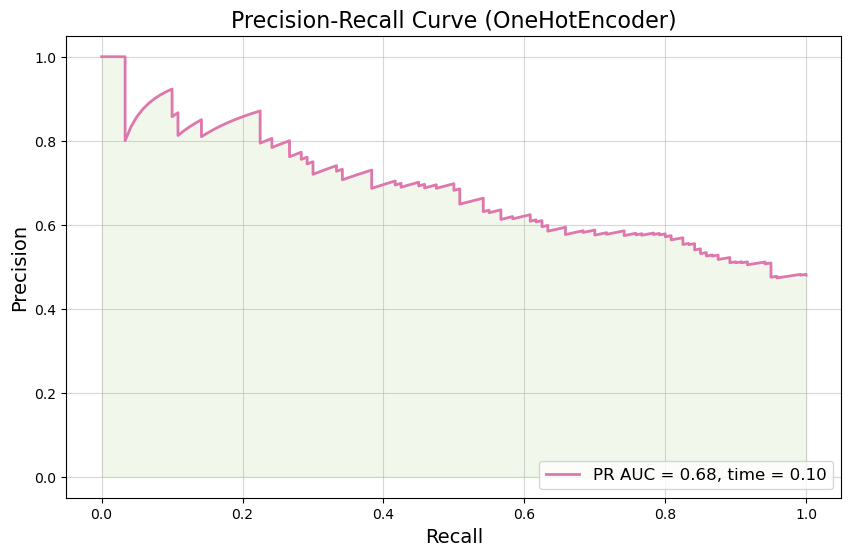

In [302]:
start = time.time()

train_encoded = X_train.copy()
test_encoded = X_test.copy()

for column in X_train.columns:
    X_train['true'] = y_train_num
    frequency = (
        X_train.groupby(column)['true']
        .transform(lambda x: ((x == 1).sum() + 5 * np.mean(y_train_num)) / (len(x) + 5))
    )
    train_encoded[column] = frequency
    test_encoded[column] = test_encoded[column].map(X_train.groupby(column)['true'].mean())
    X_train.drop(columns=['true'], inplace=True)

train_encoded_1 = train_encoded
log_reg_model = LogisticRegression(penalty='l2', C=1e9)
log_reg_model.fit(train_encoded_1, y_train_num)

end = time.time()

time_delta = end - start

y_pred = log_reg_model.predict_proba(test_encoded)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test_num, y_pred)
pr_auc = auc(recall, precision)

print(f'PR value: {pr_auc}')
print(f'Время: {time_delta}')

plt.figure(figsize=(10, 6))
plt.title('Precision-Recall Curve (OneHotEncoder)', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.plot(recall, precision, color=colors(0.8), lw=2, label=f'PR AUC = {pr_auc:.2f}, time = {time_delta:.2f}')
plt.fill_between(recall, precision, alpha=0.1, color=colors(0.2))

plt.grid(alpha=0.5)
plt.legend(loc='lower right', fontsize=12)

plt.show()

> __Замечание.__ Усложнение методов вычисления счётчиков не делают результаты модели гарантированно лучше. Особенно с учётом того, что логистическая регрессия не такая сложная модель, чтобы переобучаться. Поэтому вы необязательно должны были получать на каждом шаге всё лучшие и лучшие результаты (но необходимые результаты у вас должны были получиться).



Как мы могли пронаблюдать, счётчики являются конкурентной альтернативой one-hot-кодированию. Опишите, какие плюсы и минусы использования счётчиков по сравнению с one-hot-кодированием вы заметили.

__Ответ:__ 

Счетчики позволяют не раздувать датафрейм, что делает процесс обучение быстрее и снижают проблемы разреженны матриц (много нулей), что тоже хорошо для обновления весов градиентного спуска. Тем не менее счетчики строятся на основе таргета - что всегда сопряжено с риском ликов информации о таргете в обучающую выборку

# Часть 3. Отбор признаков (2 балла)

Загрузим данные [UCI Adult Dataset](https://archive.ics.uci.edu/ml/datasets/Adult). Этот набор данных содержит информацию о годовых доходах отдельных людей. В качестве признакового описания используется различная информация о человеке (образование, профессия, брачный статус и т.д.). Целевая переменная является бинарной: больше ли годовой доход 50K долларов или нет.

In [304]:
#!wget https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data

In [305]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
    'income'
]

df = pd.read_csv('adult.data', header=None, names=columns)
df['income'] = (df['income'] != " <=50K").astype('int32')
df.sample()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
6090,34,Private,304872,9th,5,Divorced,Other-service,Unmarried,White,Female,0,0,40,United-States,0


Важной частью процесса построения модели является отбор признаков. На практике многие признаки оказывают малое влияние на модель (при этом их расчёт занимает время) или даже негативно сказываются на качестве модели. Попробуем несколько подходов отбора признаков, оценим, как они влияют на качество модели и сколько времени занимают.



Разделите выборку на обучающую и тестовую в соотношении 3:1. Зафиксируйте `random_state=777`, также используйте `stratify=True`.

In [313]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('income', axis=1), 
                                                    df['income'], 
                                                    test_size=0.25, 
                                                    stratify=df['income'], 
                                                    random_state=777)

Давайте закодируем все категориальные признаки с помощью One-hot Encoding. Сколько новых признаков мы получим?

In [339]:
cats = X_train.select_dtypes('object').columns
nums = X_train.select_dtypes('int64').columns

encoder = OneHotEncoder(sparse=False, drop='first')

X_train_encoded = encoder.fit_transform(X_train[cats])
encoded_feature_names = encoder.get_feature_names_out(cats)
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names)

X_test_encoded = encoder.transform(X_test[cats])
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names)

X_train_final = pd.concat([X_train[nums].reset_index(drop=True), X_train_encoded_df.reset_index(drop=True)], axis=1)
X_test_final = pd.concat([X_test[nums].reset_index(drop=True), X_test_encoded_df.reset_index(drop=True)], axis=1)

In [341]:
X_train_final.shape[1]

100

In [342]:
X_test_final.shape[1]

100

В качестве основной модели будем использовать логистическую регрессию, а целевой метрики — `AUC-PR`. Обучите модель и посчитайте качество на тестовой выборке. Давайте запомним полученное значение.

AUC-PR: 0.45034048085055794


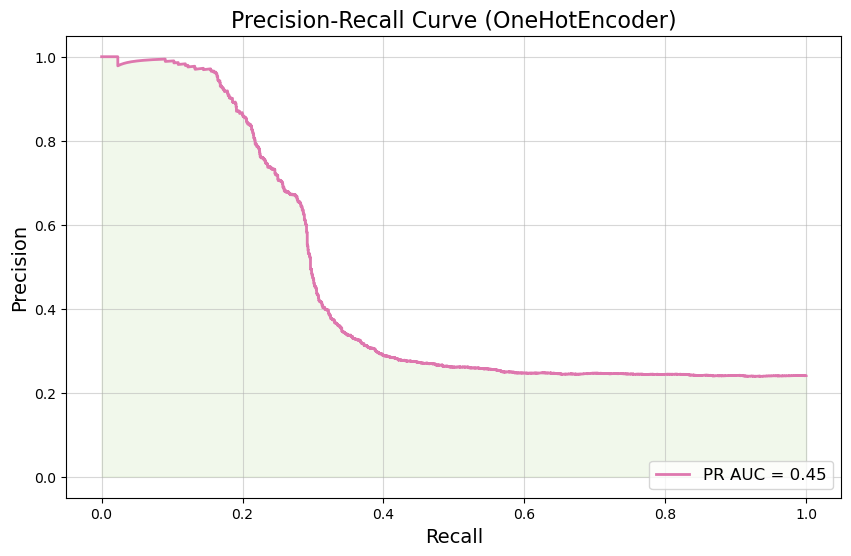

In [347]:
model = LogisticRegression(max_iter=55000)
model.fit(X_train_final, y_train)

y_pred = model.predict_proba(X_test_final)[:, 1]
precision, recall, threshold = precision_recall_curve(y_test, y_pred)
pr_auc = auc(recall, precision)

print('AUC-PR:', pr_auc)


plt.figure(figsize=(10, 6))
plt.title('Precision-Recall Curve (OneHotEncoder)', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.plot(recall, precision, color=colors(0.8), lw=2, label=f'PR AUC = {pr_auc:.2f}')
plt.fill_between(recall, precision, alpha=0.1, color=colors(0.2))

plt.grid(alpha=0.5)
plt.legend(loc='lower right', fontsize=12)

plt.show()

Допустим, мы хотим оставить только 40 лучших признаков.

Заметим, что нельзя оценивать качество по тестовой выборке, иначе мы можем переобучиться, как, например, при настройке гиперпараметров. Разделите обучающую выборку на 2 части, одну из которых, используйте для валидации. Исходную тестовую выборку стоит использовать только для финальной оценки качества после процедуры фильтрации

In [369]:
X_train, X_val, y_train, y_val = train_test_split(X_train_final, y_train, test_size=0.25, random_state=777)

Попробуем сделать это следующими способами:

#### __Задание 9. Встроенные методы (0.5 балла)__

Начнём с отбора признаков с помощью модели. У разных алгоритмов есть разные встроенные способы оценки вклада признаков в предсказание. Как известно, у линейной модели за это отвечают веса, а значит, их модуль можно интерпретировать как важность. Такой метод отбора называются встроенным или embedded method, так как он заложен в особенности модели.

Оставьте 40 признаков с наибольшим модулем соответствующего параметра линейной модели. Обучите модели заново и оцените её качество. Замерьте скорость такого отбора признаков.



In [372]:
start = time.time()
feats_40_imp = X_train_final.iloc[:, list(model.coef_.argsort()[0])[-40:]].columns
end = end.time()
feats_40_imp


Index(['native-country_ Laos', 'native-country_ Scotland',
       'native-country_ Trinadad&Tobago', 'native-country_ Honduras',
       'workclass_ Never-worked', 'native-country_ Holand-Netherlands',
       'native-country_ Thailand', 'native-country_ Hungary',
       'native-country_ Hong', 'occupation_ Armed-Forces',
       'native-country_ Iran', 'native-country_ Italy',
       'native-country_ Yugoslavia', 'native-country_ Cambodia',
       'native-country_ China', 'native-country_ England',
       'native-country_ Japan', 'occupation_ Tech-support',
       'native-country_ Canada', 'native-country_ Taiwan',
       'marital-status_ Married-AF-spouse', 'native-country_ Germany',
       'native-country_ France', 'native-country_ Philippines',
       'native-country_ Cuba', 'native-country_ India',
       'occupation_ Protective-serv', 'workclass_ Federal-gov', 'sex_ Male',
       'education_ Doctorate', 'education_ Prof-school',
       'workclass_ Self-emp-inc', 'relationship_ Wife'

In [ ]:
print(f'Время отбора: {end - start}')

AUC-PR: 0.7322323395822484


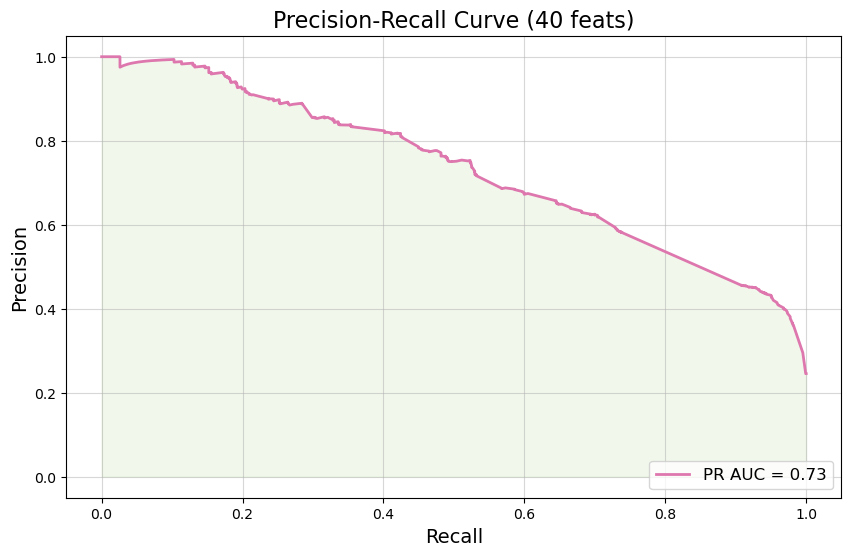

In [374]:
model = LogisticRegression(max_iter=55000)
model.fit(X_train[feats_40_imp], y_train)

y_pred = model.predict_proba(X_val[feats_40_imp])[:, 1]
precision, recall, threshold = precision_recall_curve(y_val, y_pred)
pr_auc = auc(recall, precision)

print('AUC-PR:', pr_auc)


plt.figure(figsize=(10, 6))
plt.title('Precision-Recall Curve (40 feats)', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.plot(recall, precision, color=colors(0.8), lw=2, label=f'PR AUC = {pr_auc:.2f}')
plt.fill_between(recall, precision, alpha=0.1, color=colors(0.2))

plt.grid(alpha=0.5)
plt.legend(loc='lower right', fontsize=12)

plt.show()

Изменилось ли качество? Как?

Подумаем, что мы не учли. Мы действовали в предположении, что признаки вносят вклад равномерно, и не учитывали их масштаб. Если мы умножим один из признаков в 100 раз, то без учёта регуляризации его вес уменьшится в эти же 100 раз. А мы на основе этого отбираем признаки! Давайте сначала отмасштабируем признаки одним из способов, а только потом будем удалять признаки.

Помните, что не все способы одинаково хороши, особенно в условиях наличия выбросов

Кстати, в таком случае надо пересчитать качество на всех признаках (сделайте это ниже). Если вы сделали нормирование признаков в самом начале, то попробуйте отобрать признаки на неотмасштабированных данных.

Что получилось?

In [377]:
X_train.dtypes

age                                             int64
fnlwgt                                          int64
education-num                                   int64
capital-gain                                    int64
capital-loss                                    int64
hours-per-week                                  int64
workclass_ Federal-gov                        float64
workclass_ Local-gov                          float64
workclass_ Never-worked                       float64
workclass_ Private                            float64
workclass_ Self-emp-inc                       float64
workclass_ Self-emp-not-inc                   float64
workclass_ State-gov                          float64
workclass_ Without-pay                        float64
education_ 11th                               float64
education_ 12th                               float64
education_ 1st-4th                            float64
education_ 5th-6th                            float64
education_ 7th-8th          

In [376]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
nums = X_train.select_dtypes('int64')

In [379]:
X_train_scaled = X_train.copy()
X_train_scaled[nums] = scaler.fit_transform(X_train[nums])

X_val_scaled = X_val.copy()
X_val_scaled[nums] = scaler.transform(X_val[nums])

AUC-PR: 0.7561864922694966


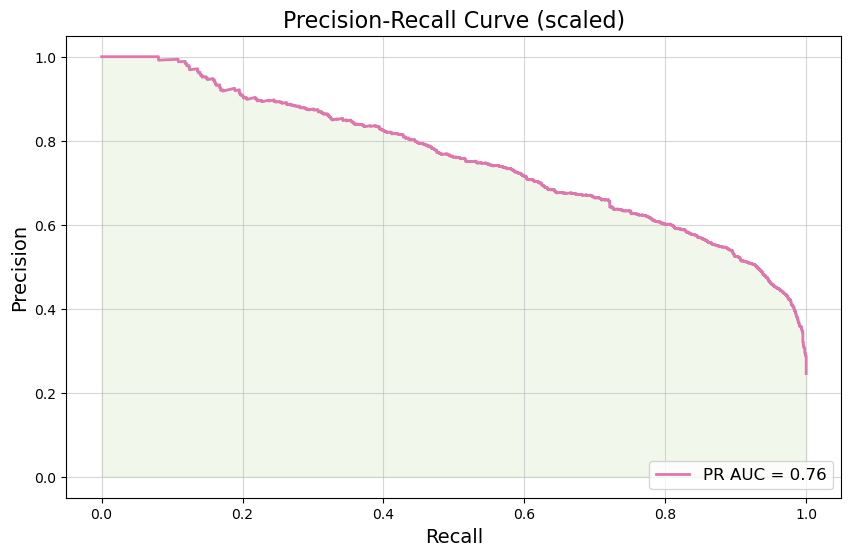

In [382]:
model = LogisticRegression(max_iter=55000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict_proba(X_val_scaled)[:, 1]
precision, recall, threshold = precision_recall_curve(y_val, y_pred)
pr_auc = auc(recall, precision)

print('AUC-PR:', pr_auc)


plt.figure(figsize=(10, 6))
plt.title('Precision-Recall Curve (scaled)', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.plot(recall, precision, color=colors(0.8), lw=2, label=f'PR AUC = {pr_auc:.2f}')
plt.fill_between(recall, precision, alpha=0.1, color=colors(0.2))

plt.grid(alpha=0.5)
plt.legend(loc='lower right', fontsize=12)

plt.show()

In [383]:
feats_40_imp_scaled = X_train_scaled.iloc[:, list(model.coef_.argsort()[0])[-40:]].columns
feats_40_imp_scaled

Index(['native-country_ England', 'native-country_ Scotland',
       'education_ 7th-8th', 'occupation_ Craft-repair',
       'race_ Asian-Pac-Islander', 'native-country_ Trinadad&Tobago',
       'marital-status_ Widowed', 'capital-loss',
       'native-country_ United-States', 'occupation_ Adm-clerical',
       'education_ Doctorate', 'race_ White', 'age', 'native-country_ France',
       'native-country_ Japan', 'workclass_ Private', 'education_ 1st-4th',
       'hours-per-week', 'workclass_ Self-emp-inc', 'native-country_ Cuba',
       'native-country_ Taiwan', 'occupation_ Sales',
       'native-country_ Yugoslavia', 'native-country_ Italy',
       'native-country_ Cambodia', 'education-num',
       'occupation_ Prof-specialty', 'occupation_ Tech-support',
       'education_ 5th-6th', 'native-country_ Philippines',
       'occupation_ Protective-serv', 'workclass_ Federal-gov',
       'native-country_ Germany', 'sex_ Male', 'native-country_ Canada',
       'occupation_ Exec-manager

Вопрос на засыпку: one-hot кодирование возвращает нам единичные признаки-индикаторы. Попробуйте также отскалировать их, как и обычные числовые, и снова выбрать 40 главных по вкладу признаков. Изменился ли их список? Изменится ли качество?

In [386]:
scaler_2 = StandardScaler()

X_train_scaled_all = X_train.copy()
X_train_scaled_all[X_train.columns] = scaler_2.fit_transform(X_train)

X_val_scaled_all = X_val.copy()
X_val_scaled_all[X_val.columns] = scaler_2.transform(X_val)

AUC-PR: 0.7560971282326029


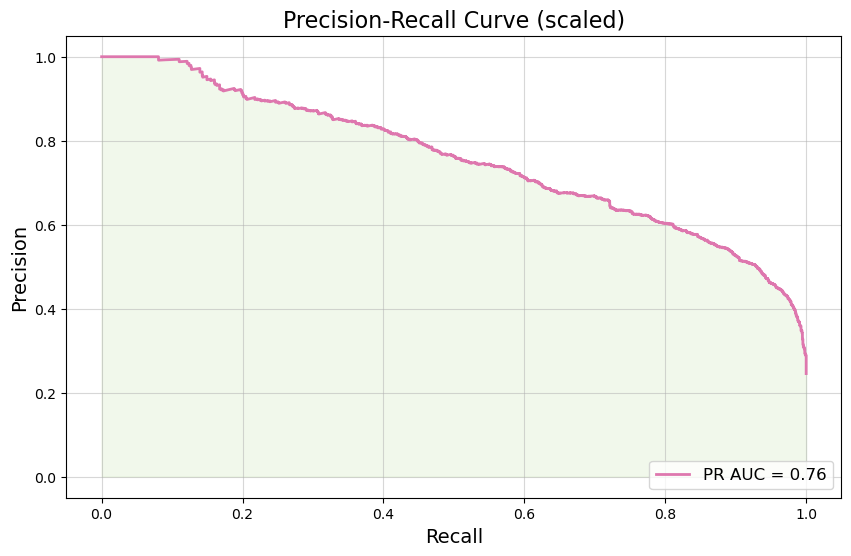

In [387]:
model = LogisticRegression(max_iter=55000)
model.fit(X_train_scaled_all, y_train)

y_pred = model.predict_proba(X_val_scaled_all)[:, 1]
precision, recall, threshold = precision_recall_curve(y_val, y_pred)
pr_auc = auc(recall, precision)

print('AUC-PR:', pr_auc)


plt.figure(figsize=(10, 6))
plt.title('Precision-Recall Curve (scaled)', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.plot(recall, precision, color=colors(0.8), lw=2, label=f'PR AUC = {pr_auc:.2f}')
plt.fill_between(recall, precision, alpha=0.1, color=colors(0.2))

plt.grid(alpha=0.5)
plt.legend(loc='lower right', fontsize=12)

plt.show()

In [388]:
feats_40_imp_scaled_all = X_train_scaled_all.iloc[:, list(model.coef_.argsort()[0])[-40:]].columns
feats_40_imp_scaled_all

Index(['native-country_ Yugoslavia', 'native-country_ Italy',
       'race_ Asian-Pac-Islander', 'marital-status_ Widowed',
       'occupation_ Craft-repair', 'workclass_ Local-gov',
       'native-country_ Canada', 'education_ Assoc-voc',
       'native-country_ Germany', 'native-country_ Philippines',
       'education_ 5th-6th', 'fnlwgt', 'occupation_ Adm-clerical',
       'native-country_ United-States', 'education_ HS-grad',
       'marital-status_ Married-AF-spouse', 'workclass_ Self-emp-inc',
       'education_ Some-college', 'occupation_ Protective-serv',
       'education_ Prof-school', 'relationship_ Unmarried',
       'occupation_ Tech-support', 'race_ White', 'education_ Doctorate',
       'occupation_ Sales', 'education_ Masters', 'workclass_ Federal-gov',
       'education_ Bachelors', 'workclass_ Private',
       'relationship_ Not-in-family', 'occupation_ Prof-specialty',
       'capital-loss', 'relationship_ Wife', 'occupation_ Exec-managerial',
       'age', 'hours-pe

In [390]:
# список изменился не сильно (30 признаков совпали), качество слегка упало (на очень малое значение)
len(set(feats_40_imp_scaled_all) & set(feats_40_imp_scaled))

30

#### __Задание 10. Методы фильтрации (0.5 балла)__


Давайте отбирать признаки умнее, а именно через подсчёт некоторой функции для каждого признака. На основании значений этой функции будем оставлять наиболее важные признаки. Методы этого семейства называют фильтрующими или  filter methods.

Одна из самых простых функция - корреляция между признаком и целевой переменной. Подумайте, какая взаимосвязь между корреляцией и предсказательной способностью модели, и как бы вы использовали информацию о корреляции для отбора признаков

**Ответ:** Корреляция - мера линейной взаимосвязи. Именно ее мы во многиз случаях "ловим" с помощью линейных моделей, поэтому чем выше корреляция в абслютном выражении тем будет лучше.

Посчитайте корреляцию каждого признака с таргетом и отфильтруйте 40 признаков исходя из того, что вы описали, после чего замерьте качество и время отбора

In [391]:
df_train = X_train_scaled.copy()
df_train['target'] = y_train

AUC-PR: 0.5631236826293883
Time: 0.6039779186248779


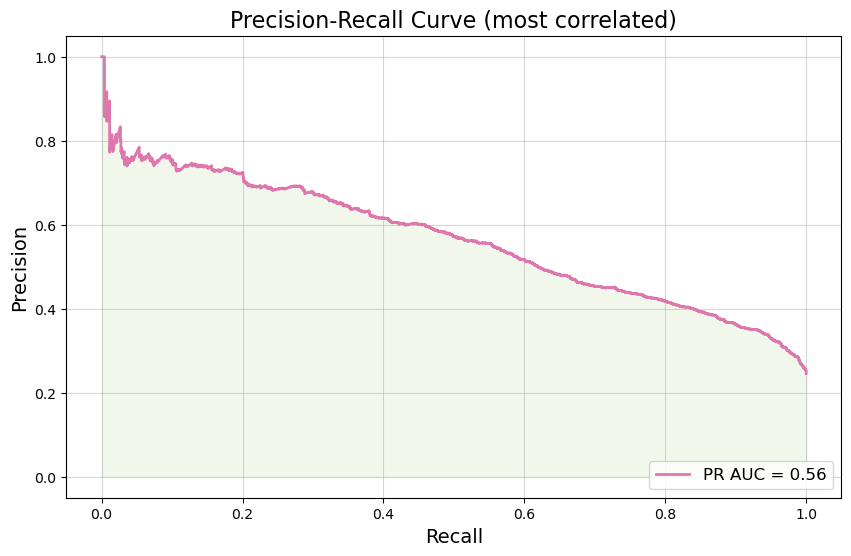

In [393]:
def select_features_by_correlation(df, target_column, n_features):
    corr = df.corr()[target_column].abs()
    selected_features = corr.nlargest(n_features).index.drop(target_column)
    return selected_features

start_time = time.time()
selected_features = select_features_by_correlation(df_train, 'target', 40)

model = LogisticRegression()
model.fit(X_train_scaled[selected_features], y_train)

y_pred = model.predict_proba(X_val_scaled[selected_features])[:, 1]

end_time = time.time()
time_taken = end_time - start_time

precision, recall, threshold = precision_recall_curve(y_val, y_pred)
pr_auc = auc(recall, precision)

print('AUC-PR:', pr_auc)
print('Time:', time_taken)

plt.figure(figsize=(10, 6))
plt.title('Precision-Recall Curve (most correlated)', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.plot(recall, precision, color=colors(0.8), lw=2, label=f'PR AUC = {pr_auc:.2f}')
plt.fill_between(recall, precision, alpha=0.1, color=colors(0.2))

plt.grid(alpha=0.5)
plt.legend(loc='lower right', fontsize=12)

plt.show()

In [394]:
selected_features

Index(['workclass_ Private', 'workclass_ Without-pay',
       'workclass_ Self-emp-inc', 'capital-loss', 'native-country_ Hong',
       'occupation_ Handlers-cleaners', 'native-country_ Haiti',
       'education_ HS-grad', 'race_ Other', 'native-country_ England',
       'marital-status_ Married-AF-spouse', 'native-country_ El-Salvador',
       'education_ Some-college', 'relationship_ Unmarried',
       'education_ 7th-8th', 'hours-per-week', 'native-country_ France',
       'native-country_ Columbia', 'native-country_ Greece',
       'native-country_ Ireland', 'native-country_ Italy',
       'relationship_ Wife', 'relationship_ Other-relative',
       'workclass_ Local-gov', 'occupation_ Exec-managerial',
       'native-country_ Trinadad&Tobago', 'fnlwgt', 'education-num',
       'education_ Prof-school', 'education_ 5th-6th', 'native-country_ South',
       'native-country_ Guatemala', 'native-country_ Thailand',
       'education_ 1st-4th', 'native-country_ Honduras',
       'nativ

В качестве еще одной функция можно считать t-статистику:

$$t(j) = \frac{|\mu_+ - \mu_-|}{\sqrt{\frac{n_+ \sigma^2_+ + n_- \sigma^2_-}{n_+ + n_-}}},$$

где $\mu$, $\sigma$, $n$ соответственно среднее, стандартное отклонение и количество объектов каждого из классов.

Оставьте 40 признаков с наибольшим значением $t$, замерьте качество и скорость отбора признаков.

AUC-PR: 0.4570755624829077
Time: 0.7356278896331787


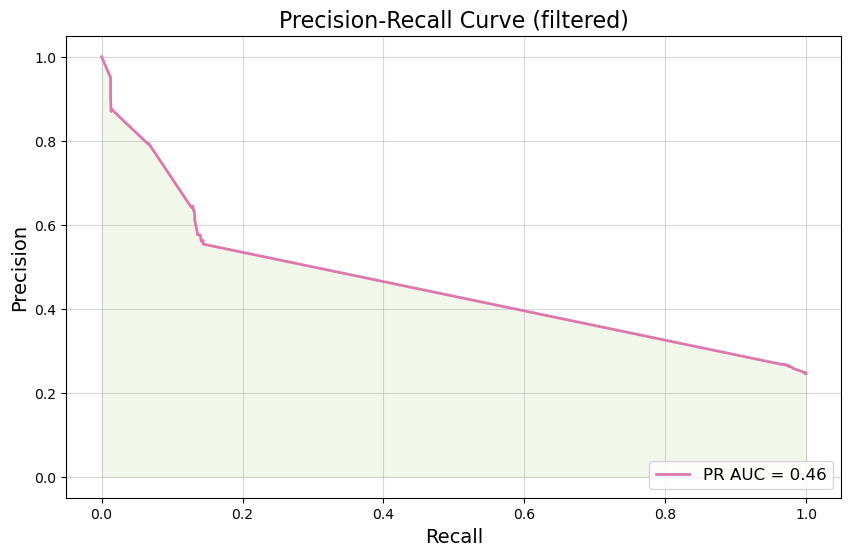

In [398]:
start = time.time()
t_statistics = {}

for column in X_train.columns:
    
    positive_group = df_train[df_train['target'] == 1][column]
    negative_group = df_train[df_train['target'] == 0][column]

    mean_positive = positive_group.mean()
    mean_negative = negative_group.mean()
    
    std_positive = positive_group.std()
    std_negative = negative_group.std()
    
    count_positive = len(positive_group)
    count_negative = len(negative_group)

    combined_variance = (count_positive * (std_positive ** 2) + count_negative * (std_negative ** 2)) / (count_positive + count_negative)

    if combined_variance != 0: # знам != 0
        t_statistic = np.abs(mean_positive - mean_negative) / combined_variance
        t_statistics[column] = t_statistic

feats_40_t_stat = sorted(t_statistics, key=t_statistics.get)[-40:]
end = time.time()

model = LogisticRegression()
model.fit(X_train_scaled[feats_40_t_stat], y_train)
y_pred = model.predict_proba(X_val_scaled[feats_40_t_stat])[:, 1]

precision, recall, threshold = precision_recall_curve(y_val, y_pred)
pr_auc = auc(recall, precision)

time_taken = end - start

print('AUC-PR:', pr_auc)
print('Time:', time_taken)

plt.figure(figsize=(10, 6))
plt.title('Precision-Recall Curve (filtered)', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.plot(recall, precision, color=colors(0.8), lw=2, label=f'PR AUC = {pr_auc:.2f}')
plt.fill_between(recall, precision, alpha=0.1, color=colors(0.2))

plt.grid(alpha=0.5)
plt.legend(loc='lower right', fontsize=12)

plt.show()

#### __Задание 11. Методы-обёртки__ (1 балл)

Третий из рассматриваемых нами методов работает следующим образом: мы исключаем признаки по очереди и смотрим, как это влияет на качество. Удаляем признаки таким жадным способом, пока не окажется выполненым некоторое условие (количество признаков или ухудшение качества). Более конкретно, алгоритм выглядит так:

- $k$ - число признаков, которых мы хотим оставить
- $m$ - число признаков, которых мы выбрасываем на каждой итерации, оно же длина шага

Шаг $i$:
- $F_i$ - набор признаков (равный всему множеству признаков на i=0)
- $M_i$ - их число, в общем случае $\max(k, M_{i-1} - m)$
1. Если признаков осталось ровно $k$, либо метрика стала уменьшаться более, чем на $\epsilon$ — останавливаемся (не наш случай, но так тоже можно)
2. Обучаем модель $a_i$ на наборе $F_i$, после чего оцениваем важность признаков (любым из способов выше или какими-нибудь ещё)
3. Отбираем $\min(M_i - k, m)$ наиболее бесполезных, согласно пункту 2, признаков (берем $m$, если можем, иначе оставляем вплоть до k), удаляем, переходим к следующему шагу

Снова оставьте только 40 признаков и оцените качество на тестовой выборке. Подберите длину шага из каких-то соображений (каких, кстати?) и замерьте время работы метода

AUC-PR: 0.6910788927949622
Time: 5.4926252365112305


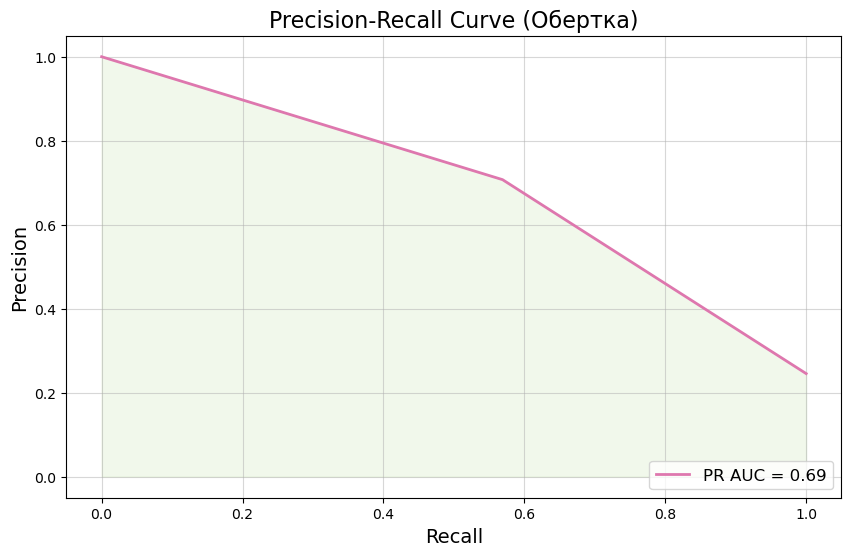

In [405]:
F_i = X_train_scaled.columns.tolist()
M_i = len(F_i)

k = 40
m = 5  
epsilon = 0.01

start = time.time()

while M_i > k:
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_scaled[F_i], y_train)

    importance_df = pd.DataFrame({'feature': F_i, 'importance': np.abs(model.coef_[0])})
    importance_df = importance_df.sort_values(by='importance')

    to_remove_count = min(m, M_i - k)

    features_to_remove = importance_df.head(to_remove_count)['feature'].tolist()
    F_i = [feature for feature in F_i if feature not in features_to_remove]
    
    M_i = len(F_i)

final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_train_scaled[F_i], y_train)
y_pred = final_model.predict(X_val_scaled[F_i])

precision, recall, threshold = precision_recall_curve(y_val, y_pred)
pr_auc = auc(recall, precision)

time_taken = end - start

end = time.time()
time_taken = end - start

print('AUC-PR:', pr_auc)
print('Time:', time_taken)

plt.figure(figsize=(10, 6))
plt.title('Precision-Recall Curve (Обертка)', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.plot(recall, precision, color=colors(0.8), lw=2, label=f'PR AUC = {pr_auc:.2f}')
plt.fill_between(recall, precision, alpha=0.1, color=colors(0.2))

plt.grid(alpha=0.5)
plt.legend(loc='lower right', fontsize=12)

plt.show()

In [404]:
print('Оставшиеся признаки:', F_i)

Оставшиеся признаки: ['education-num', 'capital-gain', 'workclass_ Federal-gov', 'workclass_ Self-emp-inc', 'workclass_ Without-pay', 'education_ 5th-6th', 'education_ Preschool', 'marital-status_ Married-AF-spouse', 'marital-status_ Married-civ-spouse', 'marital-status_ Never-married', 'marital-status_ Separated', 'occupation_ Exec-managerial', 'occupation_ Farming-fishing', 'occupation_ Handlers-cleaners', 'occupation_ Other-service', 'occupation_ Priv-house-serv', 'occupation_ Prof-specialty', 'occupation_ Protective-serv', 'occupation_ Tech-support', 'relationship_ Other-relative', 'relationship_ Own-child', 'relationship_ Wife', 'sex_ Male', 'native-country_ Cambodia', 'native-country_ Canada', 'native-country_ Columbia', 'native-country_ Dominican-Republic', 'native-country_ Ecuador', 'native-country_ El-Salvador', 'native-country_ Germany', 'native-country_ India', 'native-country_ Nicaragua', 'native-country_ Outlying-US(Guam-USVI-etc)', 'native-country_ Peru', 'native-country_

Стоит отметить, что с помощью такого метода можно пойти и в обратную сторону. Попробуйте _добавлять_ самые полезные признаки в выборку до тех пор, пока не наберется 40 штук. Найдется ли порог, при котором добавление следующих признаков будет только ухудшать качество модели?

Добавлен признак: capital-gain, скор: 0.6270
Добавлен признак: occupation_ Prof-specialty, скор: 0.6328
Добавлен признак: education_ Prof-school, скор: 0.6386
Добавлен признак: marital-status_ Married-spouse-absent, скор: 0.6396
Добавлен признак: occupation_ Tech-support, скор: 0.6401
Добавлен признак: marital-status_ Widowed, скор: 0.6411
Улучшения нет. Признак: workclass_ Never-worked, скор: 0.6411
Улучшения нет. Признак: education_ Assoc-acdm, скор: 0.6411
Улучшения нет. Признак: workclass_ State-gov, скор: 0.6411
Улучшения нет. Признак: workclass_ Without-pay, скор: 0.6411
Улучшения нет. Признак: marital-status_ Married-AF-spouse, скор: 0.6411
Улучшения нет. Признак: education_ Preschool, скор: 0.6411
Улучшения нет. Признак: occupation_ Armed-Forces, скор: 0.6411
Улучшения нет. Признак: native-country_ Cambodia, скор: 0.6411
Улучшения нет. Признак: native-country_ Canada, скор: 0.6411
Улучшения нет. Признак: occupation_ Transport-moving, скор: 0.6411
Улучшения нет. Признак: native-

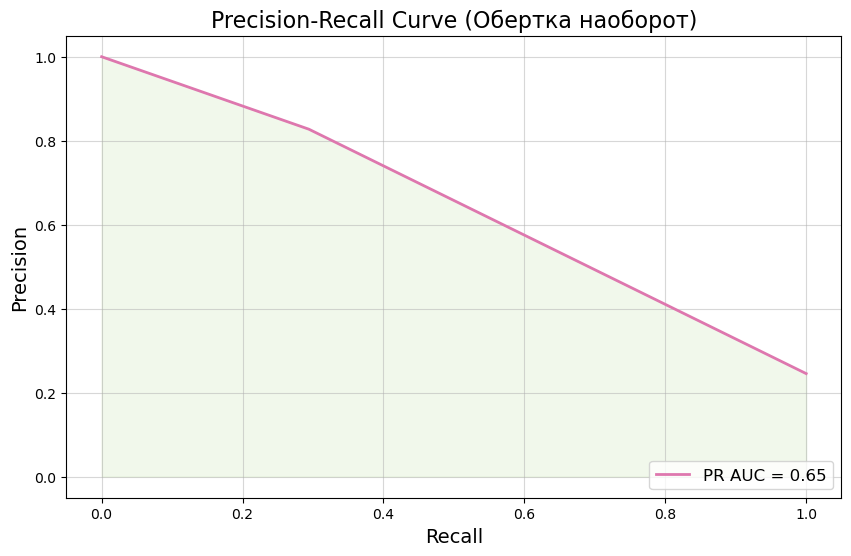

In [415]:
k = 40

F_i = []
available_features = X_train_scaled.columns.tolist()
best_auc = 0

start = time.time()

while len(F_i) < k and available_features:
    pr_scores = []
    
    for feature in available_features:
        temp_features = F_i + [feature]
        
        model = LogisticRegression(random_state=777)
        model.fit(X_train_scaled[temp_features], y_train)

        y_pred = model.predict(X_val_scaled[temp_features])
        precision, recall, threshold = precision_recall_curve(y_val, y_pred)
        pr_auc = auc(recall, precision)
        pr_scores.append((pr_auc, feature))

    best_score, best_feature = max(pr_scores, key=lambda x: x[0])
    
    if best_score > best_auc:
        best_auc = best_score
        F_i.append(best_feature)
        available_features.remove(best_feature)
        print(f'Добавлен признак: {best_feature}, скор: {best_auc:.4f}')
    else:
        print(f'Улучшения нет. Признак: {best_feature}, скор: {best_score:.4f}')
        available_features.remove(best_feature)
        F_i.append(best_feature)
        #break  # Если не было улучшения, выходим из цикла

final_model = LogisticRegression(random_state=777)
final_model.fit(X_train_scaled[F_i], y_train)
y_pred = final_model.predict(X_val_scaled[F_i])

precision, recall, threshold = precision_recall_curve(y_val, y_pred)
pr_auc = auc(recall, precision)

time_taken = end - start

end = time.time()
time_taken = end - start

print('AUC-PR:', pr_auc)
print('Time:', time_taken)

plt.figure(figsize=(10, 6))
plt.title('Precision-Recall Curve (Обертка наоборот)', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.plot(recall, precision, color=colors(0.8), lw=2, label=f'PR AUC = {pr_auc:.2f}')
plt.fill_between(recall, precision, alpha=0.1, color=colors(0.2))

plt.grid(alpha=0.5)
plt.legend(loc='lower right', fontsize=12)

plt.show()

Давайте подведём итоги по отбору признаков. Назовите преимущества и недостатки каждого из методов. Какой метод привёл к наилучшему качеству?

**Ответ:** Наилучшая качество дала "Обертка", ближайшее к ней - "обратная обертка". Корреляция справилась не так хорошо, потому что не всегда именно линейная связь отражает истинную взаимосвязь междду признаками.

# Часть 4. Оценка экономического эффекта модели (2 балла)



В данной части мы займемся тем, что от вас скорее всего потребуется на реальной работе (помимо перекладки `json`, разумеется). А именно:
- мы соберем несколько специализированных метрик качества,
- попытаемся настроить модель на максимизацию _прибыли_,
- оценим, сколько вообще получится заработать на этом.

Разумеется, здесь будет сделано множество упрощающих жизнь допущений, но обо всем по порядку. Если вы всё прослушали на экономике, то напомним, что выручка — это сколько денег нам принесли клиенты, а прибыль — выручка за вычетом расходов на зарплату и прочее.


#### __Задание 12. Прогноз по доходам и расходам__ (1 балл)

В этой части мы будем работать с данными [UCI Bank Marketing Dataset](https://archive.ics.uci.edu/ml/datasets/bank+marketing). Этот датасет содержит информацию о банковском телефонном маркетинге.

__Объектом__ здесь является телефонный звонок потенциальному клиенту с предложением некоторой услуги (утверждается, что это краткосрочный депозит). В качестве признакового описания используются характеристики клиента (образование, брак и т.д.), данные о звонке и различные экономические индикаторы - более подробная информация представлена в файле `bank-additional-names.txt`.
__Целевая переменная__ - ответ клиента (согласился ли он открыть депозит?)

In [417]:
#!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip
#!unzip bank-additional.zip
df = pd.read_csv('bank-additional-full.csv', sep=';')

In [418]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [419]:
X = df.drop(columns=['duration', 'y'])
y = (df.y == 'yes')

В этой части не нужно делить выборку - мы будем использовать кросс-валидацию.  Используйте наиболее подходящие с вашей точки зрения параметры и их значения (`shuffle`, `stratify`, число фолдов, ...). По кросс-валидации у вас получится несколько вариантов обучающей и тестовой выборки. Для удобства можно воспользоваться шаблоном ниже, который по ходу выполнения задания будет обрастать функционалом. Как обычно, это необязательно, но сохранять результаты экспериментов очень и очень желательно, в конце мы будем их сравнивать

In [427]:
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [471]:
def cross_validate(X, y, n_splits=5, random_state=None, shuffle=True, C=0.1):
    metrics = []
    incomes = []
    costs = []
    profits = []
    incomes_not_fixed = []
    profits_not_fixed = []
    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)

    categorical_features = X.select_dtypes(include=['object']).columns.tolist()
    numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features),
            ('cat', OneHotEncoder(), categorical_features)
        ])

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Создаем пайплайн с предобработкой и моделью
        model = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', LogisticRegression(max_iter=1000, C=C))
        ])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        precision, recall, threshold = precision_recall_curve(y_test, y_pred)
        pr_auc = auc(recall, precision)

         # Расчет доходов (fixed)
        income = 10 * np.sum((y_pred == 1) & (y_test == 1))
        incomes.append(income)

        # Расчет доходов (not fixed)
        income_not_fixed = np.sum(np.random.uniform(0, 20, len((y_pred == 1) & (y_test == 1))) * ((y_pred == 1) & (y_test == 1)))
        incomes_not_fixed.append(income_not_fixed)
        
        # Расчет затрат
        cost = 2 * np.sum(y_pred)  # Затраты на каждый положительный прогноз
        costs.append(cost)
        
        # Расчет прибыли (fixed)
        profit = income - cost
        profits.append(profit)

        # Расчет прибыли (not fixed)
        profit_not_fixed = income_not_fixed - cost
        profits_not_fixed.append(profit_not_fixed)

        metrics.append({
            "pr_auc": pr_auc,
            "n_train": len(y_train),
            "n_test": len(y_test)
        })
    
    return pd.DataFrame(metrics), incomes, costs, profits, incomes_not_fixed, profits_not_fixed

Выберите метрику классификации, которая вам кажется подходящей, и обучите логистическую регрессию на каждой обучающей выборке (закодируйте категориальные признаки способом, который выше вам понравился больше всех, отнормируйте числовые, гиперпараметры оставьте по умолчанию), сделайте предсказания для соответствующих тестовых выборок, выведите результаты

In [472]:
metrics, incomes, costs, profits, incomes_not_fixed, profits_not_fixed = cross_validate(X, y)
print(metrics)

     pr_auc  n_train  n_test
0  0.509283    32950    8238
1  0.481660    32950    8238
2  0.507433    32950    8238
3  0.490906    32951    8237
4  0.459454    32951    8237


Допустим, работники вашего колл-центра получают за один звонок клиенту 2 доллара. При согласии клиента на предлагаемые условия он принесет в банк 10 долларов. Предположим, что всем положительным прогнозам ваши сотрудники решили позвонить.

В качестве бизнес-метрики в нашей задаче мы будем считать прибыль aka `profit`, соответственно лучшую модель будем выбирать исходя из этого.
Посчитайте на всех тестовых выборках выручку и сохраните результаты для бизнес-метрики вместе с предыдущей метрикой, которую вы выбрали

Ответьте на вопросы:
- Сколько денег вы в среднем заработаете?
- Какое получилось стандартное отклонение профита?
- Сколько из заработанных денег придётся отдать операторам вашего колл-центра?
- Пропорциональна ли бизнес-метрика выбранной метрике классификации?

In [473]:
mean_income = np.mean(incomes)
std_income = np.std(incomes)

mean_cost = np.mean(costs)
std_cost = np.std(costs)

mean_profit = np.mean(profits)
std_profit = np.std(profits)

results_df = pd.DataFrame({
    'income': incomes,
    'cost': costs,
    'profit': profits,
    'pr_score': metrics['pr_auc']
})

correlation_profit_f1 = results_df['profit'].corr(results_df['pr_score'])

print(f"Средний заработок (income): {mean_income}, стандарнтное отклонение: {std_income}")
print(f"Средние издержки (деньги операторам колл-центра): {mean_cost}, стандарнтное отклонение:: {std_cost}")
print(f"Средняя прибыль (profit): {mean_profit}, стандартное отклонение профита: {std_profit}")
print(f"Корреляция между прибылью и Pr-score (пропорциональность бизнес-метрик): {correlation_profit_f1}")

# Интерпретация корреляции
if correlation_profit_f1 > 0.5:
    print("Существует сильная положительная корреляция между прибылью и Pr-score.")
elif correlation_profit_f1 < -0.5:
    print("Существует сильная отрицательная корреляция между прибылью и Pr-score.")
elif correlation_profit_f1 > 0.3:
    print("Существует умеренная положительная корреляция между прибылью и Pr-score.")
elif correlation_profit_f1 < -0.3:
    print("Существует умеренная отрицательная корреляция между прибылью и Pr-score.")
else:
    print("Корреляция между прибылью и Pr-score слабая.")

Средний заработок (income): 2092.0, стандарнтное отклонение: 139.05394636614957
Средние издержки (деньги операторам колл-центра): 627.2, стандарнтное отклонение:: 25.06312031651287
Средняя прибыль (profit): 1464.8, стандартное отклонение профита: 120.53613566063913
Корреляция между прибылью и Pr-score (пропорциональность бизнес-метрик): 0.9707311078323683
Существует сильная положительная корреляция между прибылью и Pr-score.


Внесем некоторую долю случайности. Пусть теперь согласный на условия клиент будет приносить не 10 долларов, а случайную величину, равномерно распределенную в интервале $[0;20)$. Проделайте все те же самые действия. Для имитации реальной ситуации **НЕ** фиксируйте `random_seed` при подсчете выручки с клиента (для разбиения на фолды разумеется оставьте). Что получилось?

In [474]:
mean_income = np.mean(incomes_not_fixed)
std_income = np.std(incomes_not_fixed)

mean_cost = np.mean(costs)
std_cost = np.std(costs)

mean_profit = np.mean(profits_not_fixed)
std_profit = np.std(profits_not_fixed)

results_df = pd.DataFrame({
    'income': incomes_not_fixed,
    'cost': costs,
    'profit': profits_not_fixed,
    'pr_score': metrics['pr_auc']
})

correlation_profit_f1 = results_df['profit'].corr(results_df['pr_score'])

print(f"Средний заработок (income): {mean_income}, стандарнтное отклонение: {std_income}")
print(f"Средние издержки (деньги операторам колл-центра): {mean_cost}, стандарнтное отклонение:: {std_cost}")
print(f"Средняя прибыль (profit): {mean_profit}, стандартное отклонение профита: {std_profit}")
print(f"Корреляция между прибылью и Pr-score (пропорциональность бизнес-метрик): {correlation_profit_f1}")

# Интерпретация корреляции
if correlation_profit_f1 > 0.5:
    print("Существует сильная положительная корреляция между прибылью и Pr-score.")
elif correlation_profit_f1 < -0.5:
    print("Существует сильная отрицательная корреляция между прибылью и Pr-score.")
elif correlation_profit_f1 > 0.3:
    print("Существует умеренная положительная корреляция между прибылью и Pr-score.")
elif correlation_profit_f1 < -0.3:
    print("Существует умеренная отрицательная корреляция между прибылью и Pr-score.")
else:
    print("Корреляция между прибылью и Pr-score слабая.")

Средний заработок (income): 2110.1490169960875, стандарнтное отклонение: 193.58225107965825
Средние издержки (деньги операторам колл-центра): 627.2, стандарнтное отклонение:: 25.06312031651287
Средняя прибыль (profit): 1482.9490169960875, стандартное отклонение профита: 174.77379258454994
Корреляция между прибылью и Pr-score (пропорциональность бизнес-метрик): 0.9393878350070782
Существует сильная положительная корреляция между прибылью и Pr-score.


Настройте по кросс-валидации коэффициент регуляризации модели для максимизации прибыли (считайте как случайную величину выше). Удалось ли получить какой-то выигрыш? При каком коэффициенте регуляризациии прибыль максимальна? Постройте график зависимости ожидаемой прибыли от коэффициента

In [476]:
from tqdm import tqdm

In [477]:
Cs = []
profitss = []
for C in tqdm(np.logspace(-3, 3, 20)):
    metrics, incomes, costs, profits, incomes_not_fixed, profits_not_fixed = cross_validate(X, y)
    Cs.append(C)
    profitss.append(np.mean(profits_not_fixed))
    

100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [01:11<00:00,  3.58s/it]


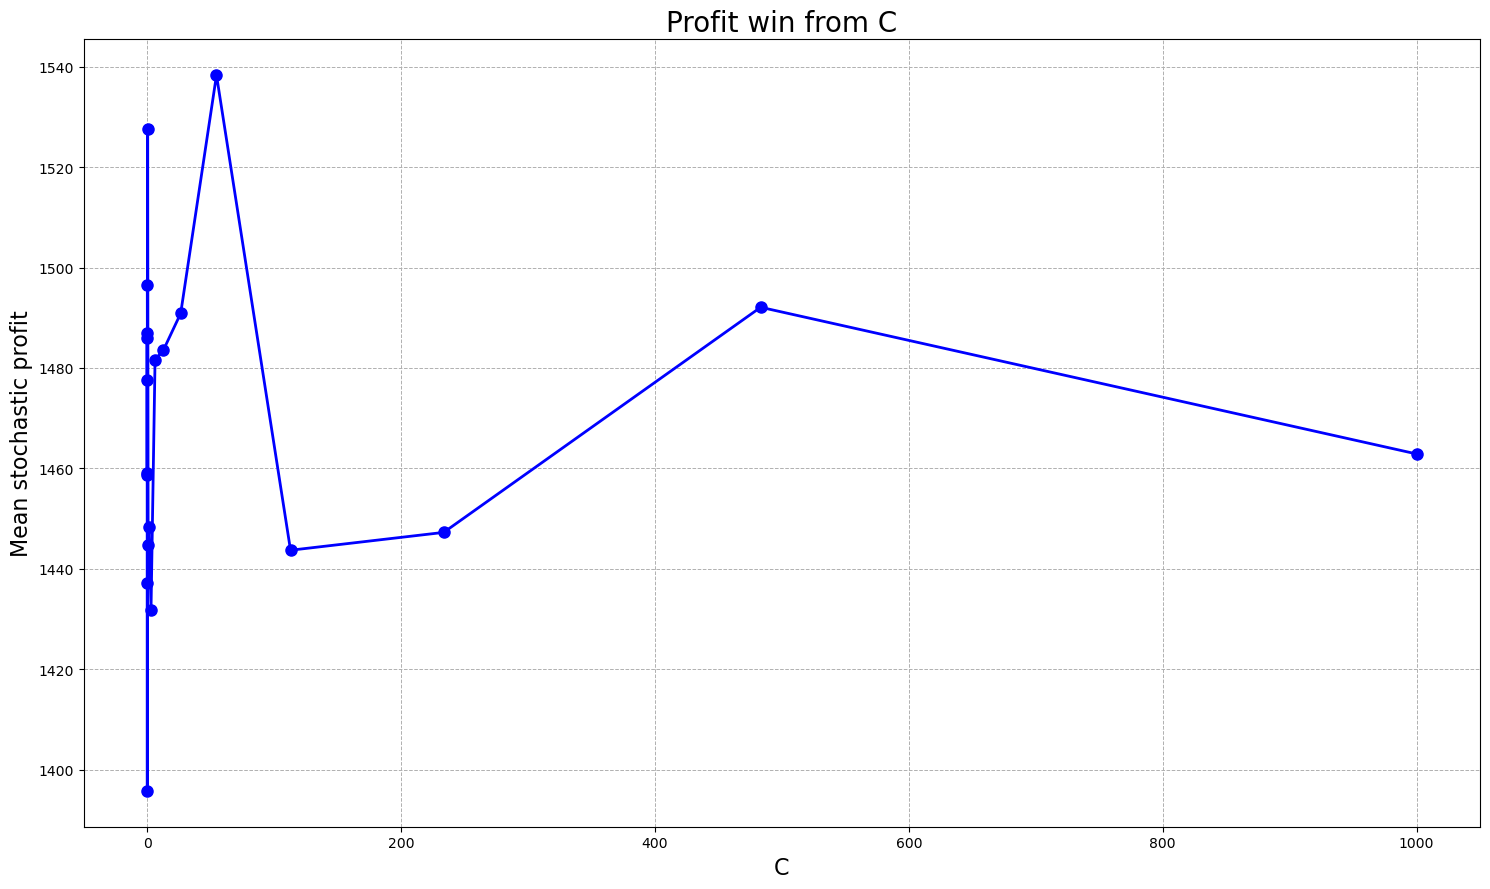

In [483]:
fig, ax = plt.subplots(figsize=(15, 9))

ax.plot(Cs, profitss, marker='o', linestyle='-', color='b', markersize=8, linewidth=2)

ax.set_xlabel('C', fontsize=16)
ax.set_ylabel('Mean stochastic profit', fontsize=16)
ax.set_title('Profit win from C', fontsize=20)

ax.grid(which='both', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

Попробуйте запустить перебор несколько раз. Находится ли каждый раз один и тот же "лучший" коэффициент? Присутствует ли какая-то закономерность? Какие вы можете сделать из этого выводы?

Iter: 4: 100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:18<00:00,  3.78s/it]
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


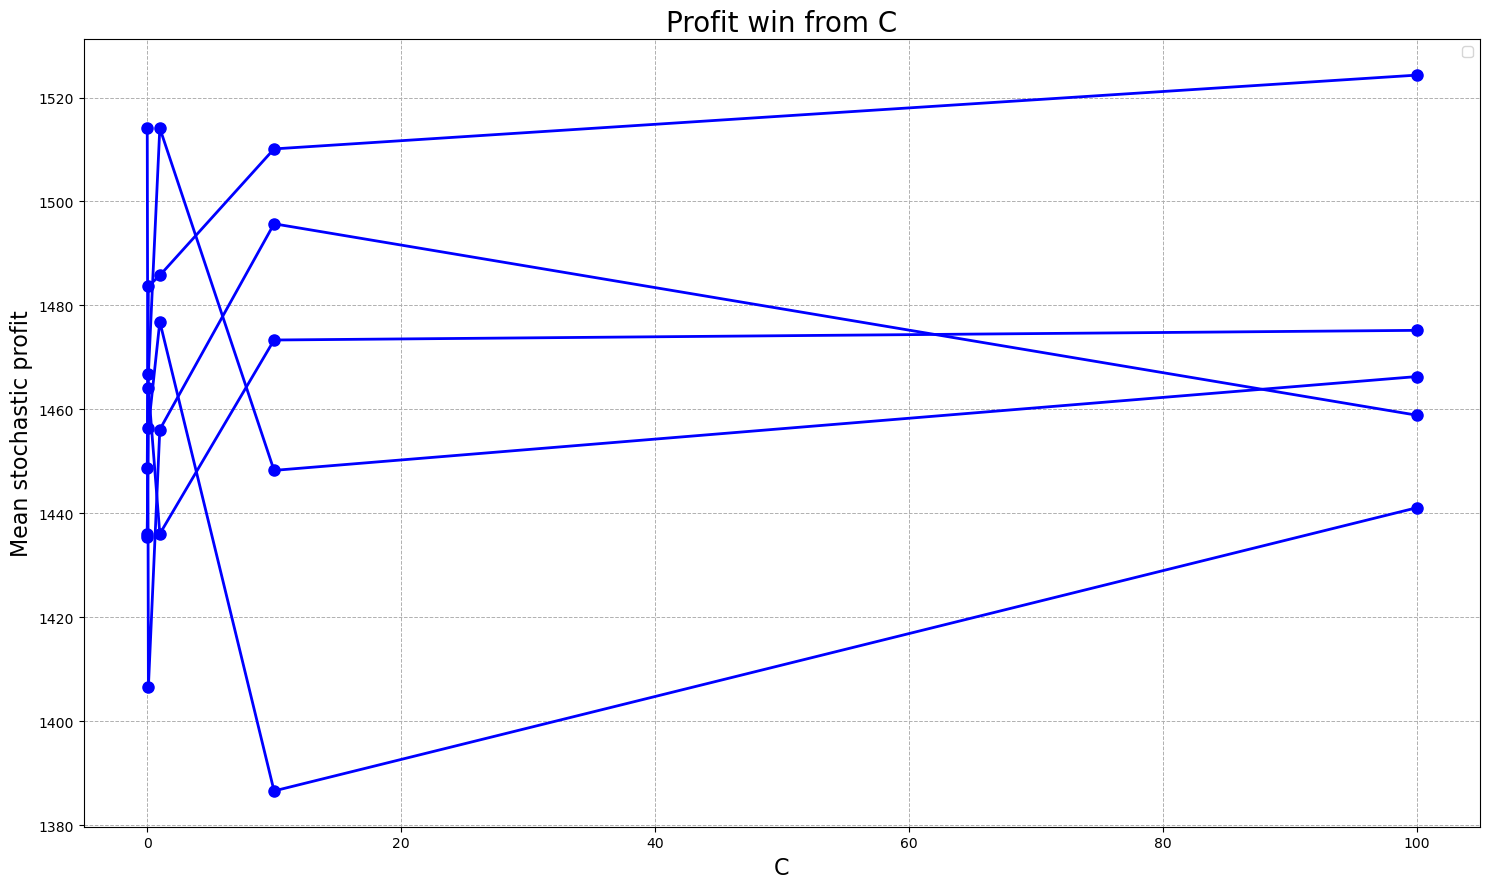

In [494]:
fig, ax = plt.subplots(1, figsize=(15, 9))
for i in range(5):
    Cs = []
    profitss = []
    for C in tqdm(np.logspace(-2, 2, 5), desc=f'Iter: {i}'):
        try:
            metrics, incomes, costs, profits, incomes_not_fixed, profits_not_fixed = cross_validate(X, y)
            Cs.append(C)
            profitss.append(np.mean(profits_not_fixed))
        except:
            pass
    ax.plot(Cs, profitss, marker='o', linestyle='-', color='b', markersize=8, linewidth=2)

ax.set_xlabel('C', fontsize=16)
ax.set_ylabel('Mean stochastic profit', fontsize=16)
ax.set_title('Profit win from C', fontsize=20)

ax.grid(which='both', linestyle='--', linewidth=0.7)

plt.tight_layout()
ax.legend()
plt.show()

На разных итерациях - результаты все же различаются, хотя общая траектория в целом похожа. Но нет одного наилучшего C.

#### __Задание 13. Ключевая метрика__ (1 балл)

Выше мы уже описали примерную экономическую модель вашей задачи. Как вы считаете, что для вашего бизнеса важнее — хороший precision или recall модели? Почему?

__Ответ:__ Важна точность, потому что за лишние звонки мы несем убыток, который не окупается

> Вспомним, что на самом деле логистическая регрессия предсказывает нам вероятности положительного класса для объекта. Возможно, путем настройки __порога бинаризации__ этих вероятностей мы сможем получить какой-то выигрыш?

Проверьте ваши рассуждения выше с помощью настройки порога бинаризации на кросс-валидации для максимизации прибыли. Воспользуйтесь сеткой от 0 до 1 с шагом 0.01. Напомним, что снижение порога дает нам более высокий recall и более низкий precision, и наоборот. Добавьте новую ML-метрику в ваш CV-пайплайн, найдите такой порог, при котором бизнес-метрика максимальна, и проверьте, связана ли новая ML метрика с профитом

In [ ]:
# your code here

Постройте график зависимости прибыли от порога бинаризации. Выделите наилучший порог




In [ ]:
# your code here

__Вопрос:__ Замечаете ли вы какую-то закономерность? Для правильного ответа на этот вопрос попробуйте запустить несколько раз и задумайтесь, почему порог получается в какой-то конкретной области?

__Ответ:__ # your answer here

Наконец, чтобы точнее понять, что наша модель лучше исходной, посчитайте среднее и стандартное отклонение по фолдам бизнес-метрики для оптимизированной модели (гиперпараметры + порог) и дефолтной логистической регрессии. Проверьте, действительно ли удалось добиться значимого изменения прибыли — примените какой-либо статистический тест (например, парный t-критерий с $\alpha=0.95$) к метрике, полученной двумя этими моделями

In [ ]:
# your code here

# __Бонусная часть. Многоклассовая классификация__ (1.5 балла)

Как известно, некоторые задачи не ограничиваются всего лишь двумя классами. На лекции вы проходили несколько способов обобщения линейных моделей на этот случай: One-vs-Rest и One-vs-One. Ниже мы посмотрим, в чём преимущества и недостатки обоих подходов, а так же попробуем ещё один чуть более экзотический метод

#### **Задание 14. One-vs-Rest vs One-vs-One** (0.5 балла)

В качестве [датасета](https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention/data) здесь и ниже мы будем брать очень жизненные и актуальные данные о том, доучится студент или нет, в зависимости от курсов, возраста, гендера и прочих (не)осуждаемых признаков.

In [ ]:
import kagglehub

path = kagglehub.dataset_download("thedevastator/higher-education-predictors-of-student-retention") + "/dataset.csv"

features = ["Marital status", "Course", "Nacionality", "Gender", "Age at enrollment"]
target = "Target"

Будем смотреть только какое-то подмножество наиболее весёлых факторов. От вас по классике потребуется их преобразовать, в зависимости от того, числовые они или категориальные и **закодировать таргет чиселками!!!**

In [ ]:
# your code here

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=228, shuffle=True, test_size=0.2)

Ваш следующий шаг - посмотреть, каким образом в `sklearn` реализованы OvR и OvO, обучить таким образом логистическую регрессию с `max_iter=10000`, далее выбрать какую-то метрику (и её усреднение, его выбор тоже аргументируйте), и сравнить следующие параметры:
- число классификаторов
- скорость обучения
- качество модели

Также сохраните куда-нибудь предсказания вероятностей у каждой из моделей. Это можно сделать не одним способом, но возможно вам чуть с этим поможет следующий пункт


In [ ]:
# your code here

Как вы объясните полученные результаты?

__Ответ:__ # your code here

#### __Задание 15. Softmax регрессия__ (1 балл)

Однако любознательные машинисты могут задаться вопросом "А зачем нам вся эта шляпа, если у сигмоиды есть обобщение на случай многоклассовой классификации?" Если вам понравилось считать градиенты в прошлом дз, или вам нравится обучать нейросети, этот пункт для вас. Здесь мы попробуем построить одну-единственную модель, которая будет всё предсказывать, а также сравним с вариантами выше

Начнём с подсчёта лосса. Вспомним, что логистическая функция потерь это частный случай кросс-энтропии, её и будем пытаться оптимизировать.

$$
\text{CE}(X, y) = -\frac{1}{N}\sum_i \sum_k [y_i = k] \log p(x_i = k)
$$
Вероятности в данном случае будем считать при помощи софтмакса, что есть общий случай сигмоиды

$$
p(x_i) = \text{Softmax}(a(x_i)); \quad
\text{Softmax}(x)_k = \frac{e^{x_{k}}}{\sum_j e^{x_{j}}} \\
$$

Предсказание модели на одном объекта будет делаться уже при помощи матрицы весов, посклоьку выходов несколько

$$
a(x_i) = x_i\cdot W \\
$$

Ниже предлагается написать код для такой функции потерь. Если необходимо, модифицируйте шаблон по своему усмотрению (вспомогательные функции, новые аргументы, всё, что душа пожелает)

In [ ]:
from typing import Iterable, Optional
from torch.nn.functional import cross_entropy
import torch

def custom_ce(
    y_pred: np.ndarray[float],
    y_true: np.ndarray[int],
) -> float:
    # your code here
    return

In [ ]:
for _ in range(1000):

    n_objects = np.random.randint(1, 100)
    n_classes = np.random.randint(2, 20)
    y_pred = np.random.normal(0, 1, (n_objects, n_classes))
    y_true = np.random.randint(low=0, high=n_classes, size=(n_objects,))

    your_ce = custom_ce(y_pred, y_true) # не забудьте поправить, если меняли шаблон
    torch_ce = cross_entropy(torch.tensor(y_pred), torch.tensor(y_true))
    assert np.allclose(your_ce, torch_ce), "Что-то пошло не так"

Дальше самая интересная часть - нужно вывести производную этой функции потерь (на всякий случай уточним, что `torch` использовать нельзя, разве что для самопроверки). Полезные факты, которые вам могут пригодиться:

- в матричном виде найти производную непросто, попробуйте сперва сделать это для одного объекта, обобщить будет полегче
- логсофтмакс дифференцировать гораздо легче, чем просто софтмакс
- не забывайте про правило дифференцирования сложной функции
- поскольку веса в данном случае матрица, результат будет тоже матрица, учтите при сверке размерностей
- если вы не придумали, как преобразовать индикаторы в векторный вид, сейчас самое время

In [ ]:
def ce_gradient(X: np.ndarray, W: np.ndarray, y: np.ndarray) -> np.ndarray[float]:
    # your code here
    return

Дальше дело за малым. Вспомните (или узнайте), как делается градиентный спуск, и дополните класс софтмакс-регрессии ниже. Здесь разумнее использовать критерий останова по итерациям, но логрег из `sklearn` устроен немного хитрее. Если хотите добавить еще критерии останова, какие-то другие параметры, то пожалуйста

In [ ]:
class SoftmaxRegression:

    def __init__(self, lr=1e-3, max_iter=10000):
        self.W = None
        self.max_iter = max_iter
        self.lr = lr

    def fit(self, X, y):
        # your code here

    def predict(self, X, y=None):
        # your code here

Обучите на тех же данных, что и выше, замерьте те же три параметра, плюс сравните значения кросс-энтропии для уже трёх моделей. Сравните модели между собой и выберите фаворита в данной задаче.

In [ ]:
# your code here

__Ответ__: # your text here

__Бонус (0.01 балла):__ что вы кушали в день сдачи данного ДЗ на завтрак?

__Ответ:__ # your answer here